In [1]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [2]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

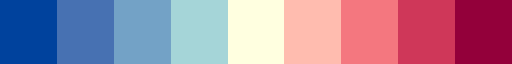

In [3]:
my_cmap

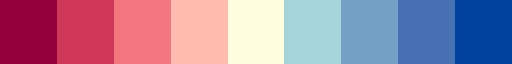

In [4]:
my_cmap_r

In [5]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def calculate_assymetricity(u,v,k):
    x=np.sqrt(np.array(u)**2+np.array(v)**2)
    y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)  
    return x,y

def characterize_case(x,y):
    if (x**2>0.5)*(y>0.5):
        return 0
    if (x**2>0.5)*(y<0.5):
        return 1
    if (x**2<0.5):
        return 2

ModuleNotFoundError: No module named 'InitializeSpeciesPool'

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

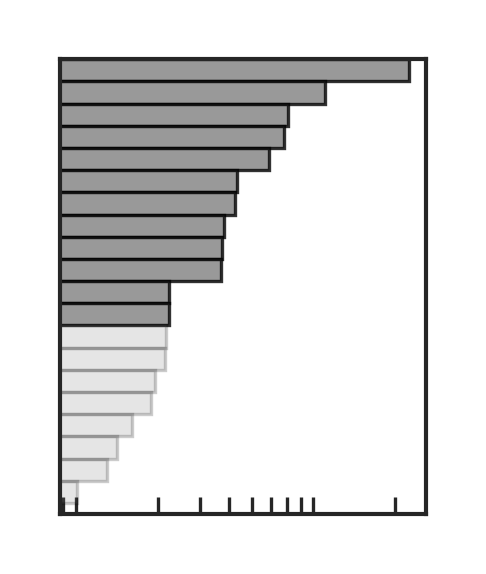

In [ ]:
abundance_rank=[]
f, ax = plt.subplots(1, figsize=(20*mm,25*mm),facecolor='w', edgecolor='k')

data_string = "2226615 981051 687452 656538 569829 416965 410814 366608 361687 356864 215769 214543 209635 206853 188438 180962 149820 130283 118260 87923 87304 71550 65388 62033 54586 49528 44617 42693 41868 40128 39318 38776 32953 29246 28125 28110 20483 15273 13335 13196 11932 9900 8841 7844 6730 5838 4379 4230 3588 2937 2489 1757 1616 1475 1203 1197 1175 1143 1048 1023 1022 946 927 910 891 763 757 726 652 627 617 605 573 538 487 477 457 450 444 441 412 392 386 374 351 337 330 327 323 320 292 290 281 279 274 269 268 266 266 263 257 256 248 248 248 244 240 235 232 227 227 224 222 222 221 219 211 211 208 207 204 202 197 195 193 192 191 188 188 184 182 180 178 175 171"
data_list = list(map(int, data_string.split()))
data_list = np.array(data_list)/sum(data_list)
N=12
plt.barh(range(N), data_list[:N], color='grey', alpha=0.8, height=1, linewidth=0.4, edgecolor='black')
M=20
plt.barh(range(N,M), data_list[N:M], color='grey', alpha=0.2, height=1, linewidth=0.4,edgecolor='black')

plt.xscale('log')  # Use a logarithmic scale for the y-axis
plt.xlabel('')  # Remove x label
plt.ylabel('')  # Remove y label
plt.xticks([])
plt.yticks([])
plt.gca().invert_yaxis()
plt.ylim([20,-0.5])

f.savefig(f'Figure/Abundance_map.png',bbox_inches='tight')


In [ ]:
# Plotting real data
degList=np.zeros(43)

data1_set={}
data2_set={}
data3_set={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    Null_model_rep=1
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
    data1=[]
    data2=[]
    data3=[]
    species_num=len(degList)
    data_null_model=[]
    for i in range(len(idx)):
        c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
        c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
        c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
        c_1=c_1*(c_1>1e-4)
        c_2=c_2*(c_2>1e-4)
        '''
            mix_label=(np.random.rand(species_num)>0.5).astype(int)
            moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
            moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
            moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
            moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)
        '''
        u,v,k=metric_VectorDecomposition_onlyPositive(c_1,c_2,c_mix)
        data1.append(u)
        data2.append(v)
        data3.append(k)

    data1_set[type_name] = data1
    data2_set[type_name] = data2
    data3_set[type_name] = data3


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


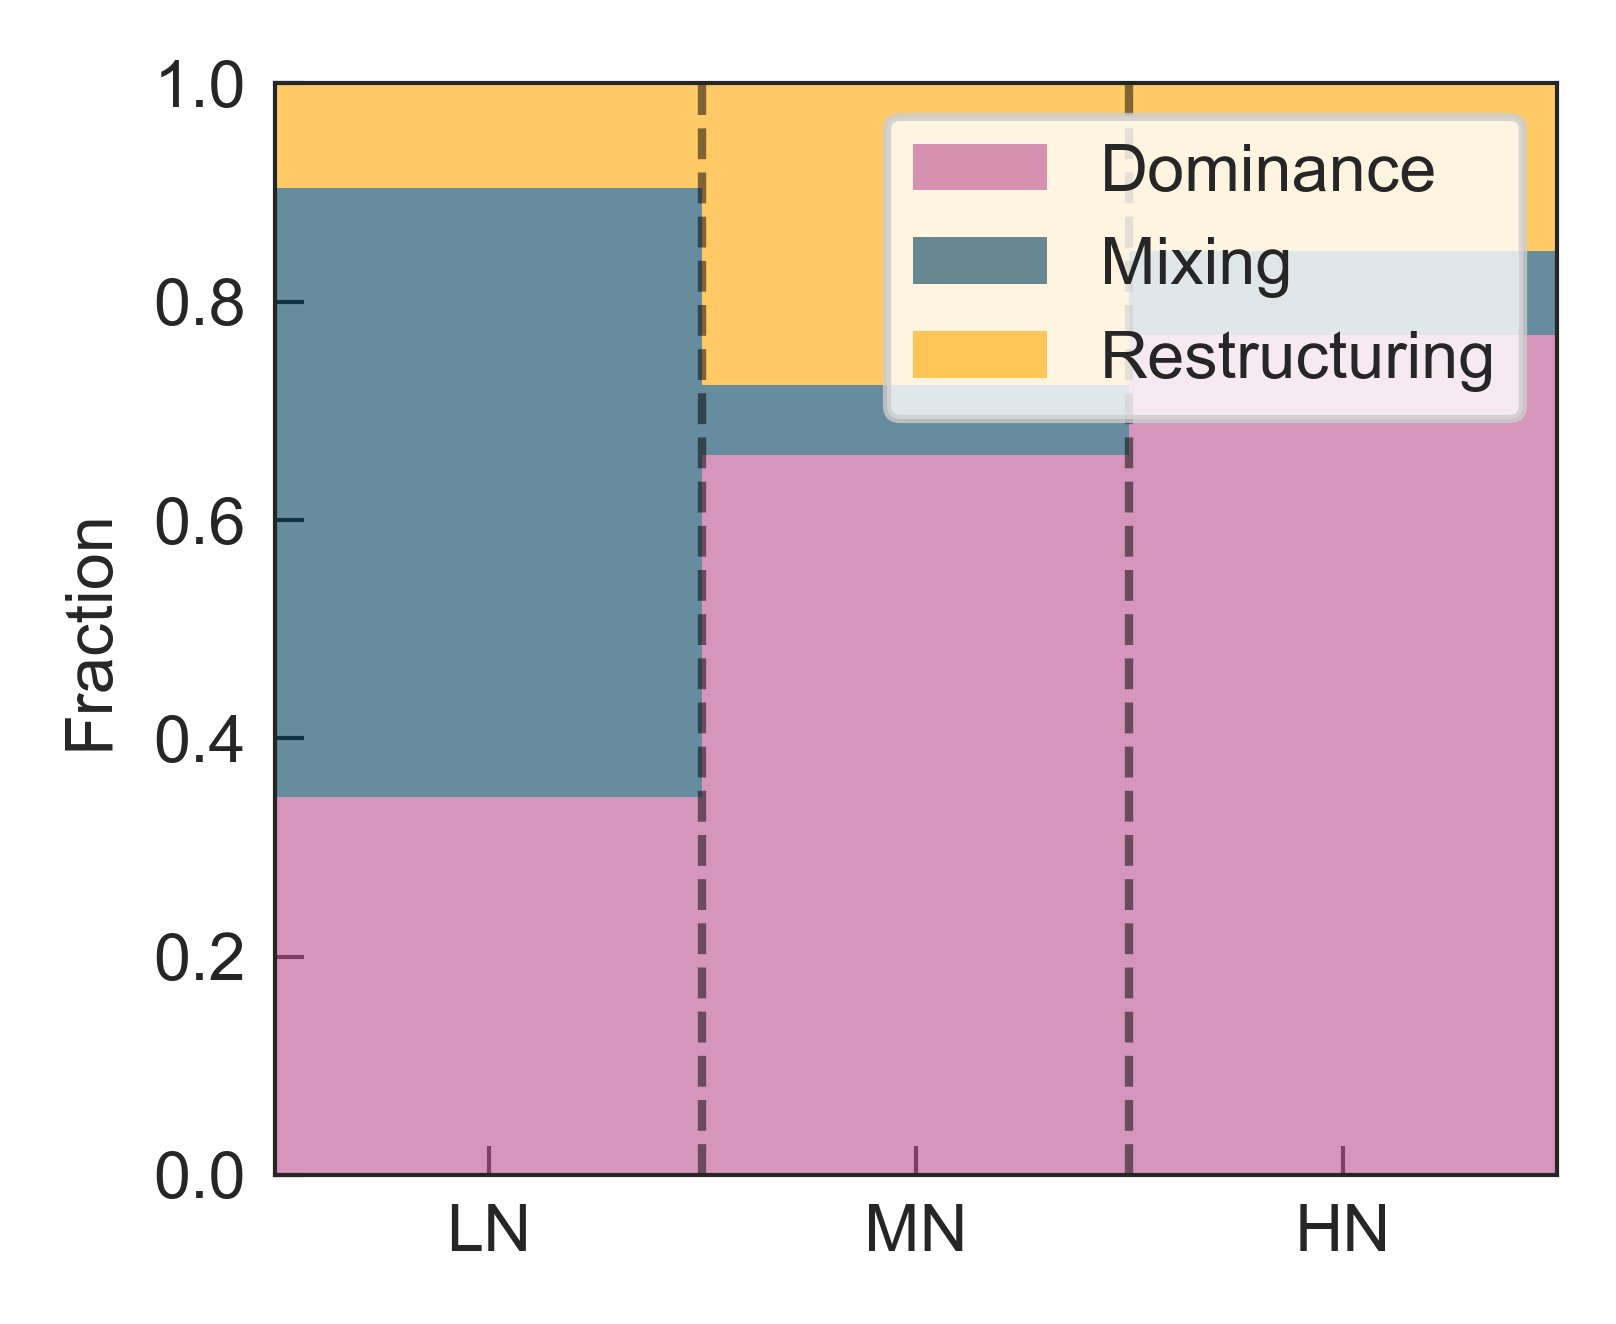

In [ ]:
class1_fractions=np.zeros(4)
class2_fractions=np.zeros(4)
class3_fractions=np.zeros(4)

colors = ['#bc5090', '#003f5c','#ffa600' ]


for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):

    class1_count=0
    class2_count=0
    class3_count=0
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        if ii==0:
            class1_count+=1
        if ii==1:
            class2_count+=1
        if ii==2:
            class3_count+=1
    total_count=class1_count+class2_count+class3_count
    class1_fractions[c_i]=class1_count/total_count
    class2_fractions[c_i]=class2_count/total_count
    class3_fractions[c_i]=class3_count/total_count
    
f, ax = plt.subplots(1, figsize=(70*mm,60*mm),facecolor='w', edgecolor='k')

    
# Create a stacked, filled bar plot for each x value
width = 0.5  # Width of the bars

# Create an array of x values for each class to form a connected line
x_values_array = np.array([0,1,2,3])

# Plot each class's fractions as stacked, filled bars
plt.fill_between(x_values_array, 0, class1_fractions, step='post', label='Dominance', color=colors[0], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions, class1_fractions + class2_fractions, step='post', label='Mixing', color=colors[1], alpha=0.6, edgecolor='none')
plt.fill_between(x_values_array, class1_fractions + class2_fractions, class3_fractions + class2_fractions + class1_fractions, color=colors[2], alpha=0.6, step='post', label='Restructuring', edgecolor='none')


# Add labels and a legend
#plt.xlabel('Mediums')
plt.ylabel('Fraction')
plt.xlim([0,3])
plt.ylim([0,1])
#plt.title('Stacked and Filled Bar Plot of Three Classes for Each X Value')
plt.legend()

plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0.5, 1.5, 2.5]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.axvline(x=2, color='black', linestyle='--', alpha=0.5, linewidth=1)

# Display the plot
f.savefig(f'Figure/Fig_classes_map.svg',bbox_inches='tight')
plt.show()

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


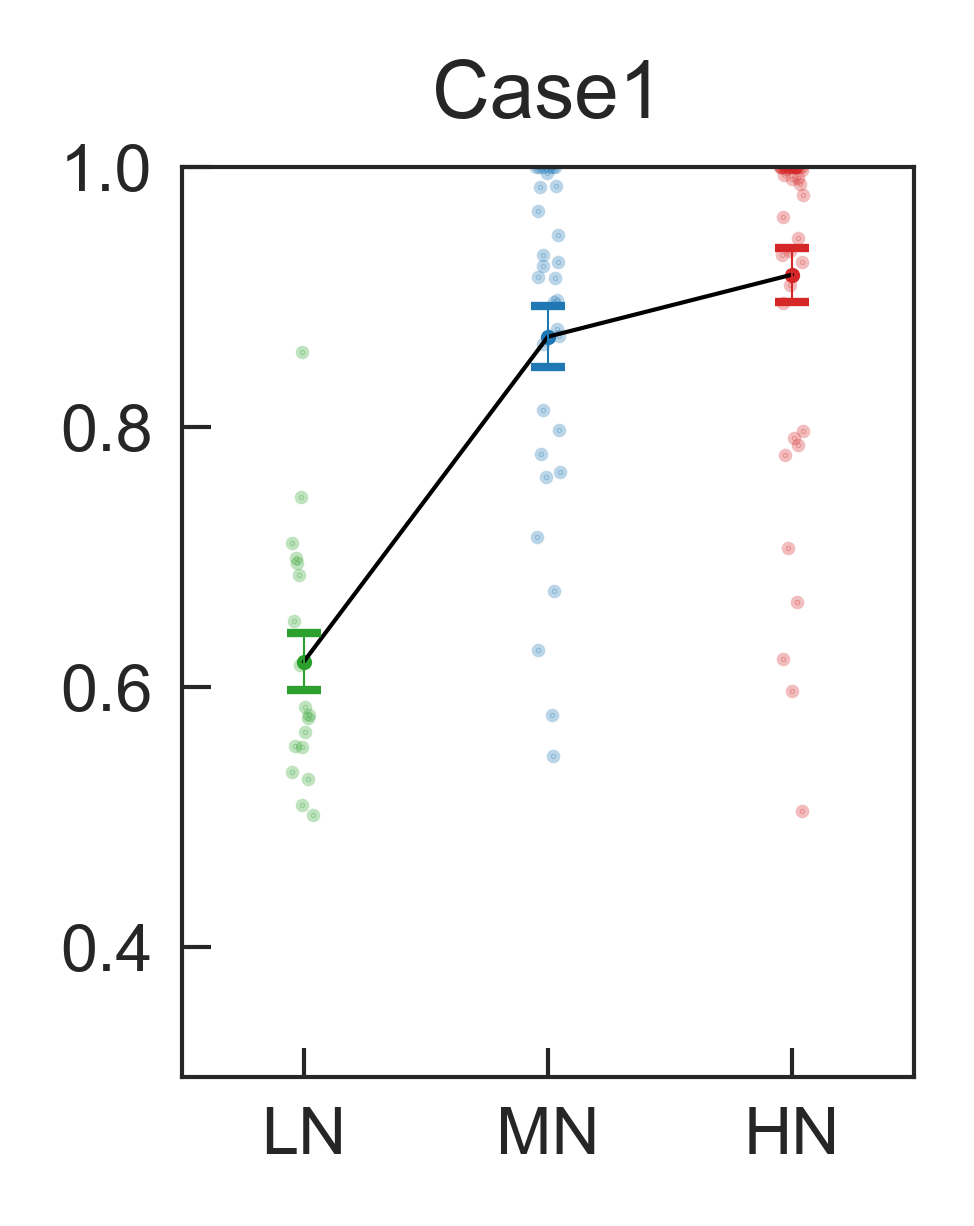

In [ ]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

    
data={}
data2={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    data_i=[]
    data_j=[]
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        if ii==0:
            data_i.append(y)
            data_j.append(x)
        if ii==1:
            continue
        if ii==2:
            continue
    total_count=class1_count+class2_count+class3_count
    data[c_i]=data_i
    data2[c_i]=data_j
    

    
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=0

x=[0,1,2]
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(3):
    if len(data[i])==0:
        continue
    random_component=(0.1*(np.random.rand(len(data[i]))-0.5))
    plt.scatter([x[i]]*len(data[i])+random_component, data[i], s=0.4, color= colors_points[i], alpha=0.3)
plt.plot(x, y,color='black', linewidth=0.5)
for i, c in enumerate(colors_points):
    plt.errorbar(x[i],y[i],yerr[i], linewidth=0.25, color=c, elinewidth=.25, capsize=2,capthick=1)
    plt.scatter(x[i],y[i],  linewidth=0.25, color=c, s=2.5)



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('y')
# Add custom x tick labels

plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0, 1, 2]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)

plt.xlim(-0.5, 2.5)
plt.ylim(0.3, 1)
plt.title('Case1')

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_case1_y.svg', bbox_inches='tight')


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


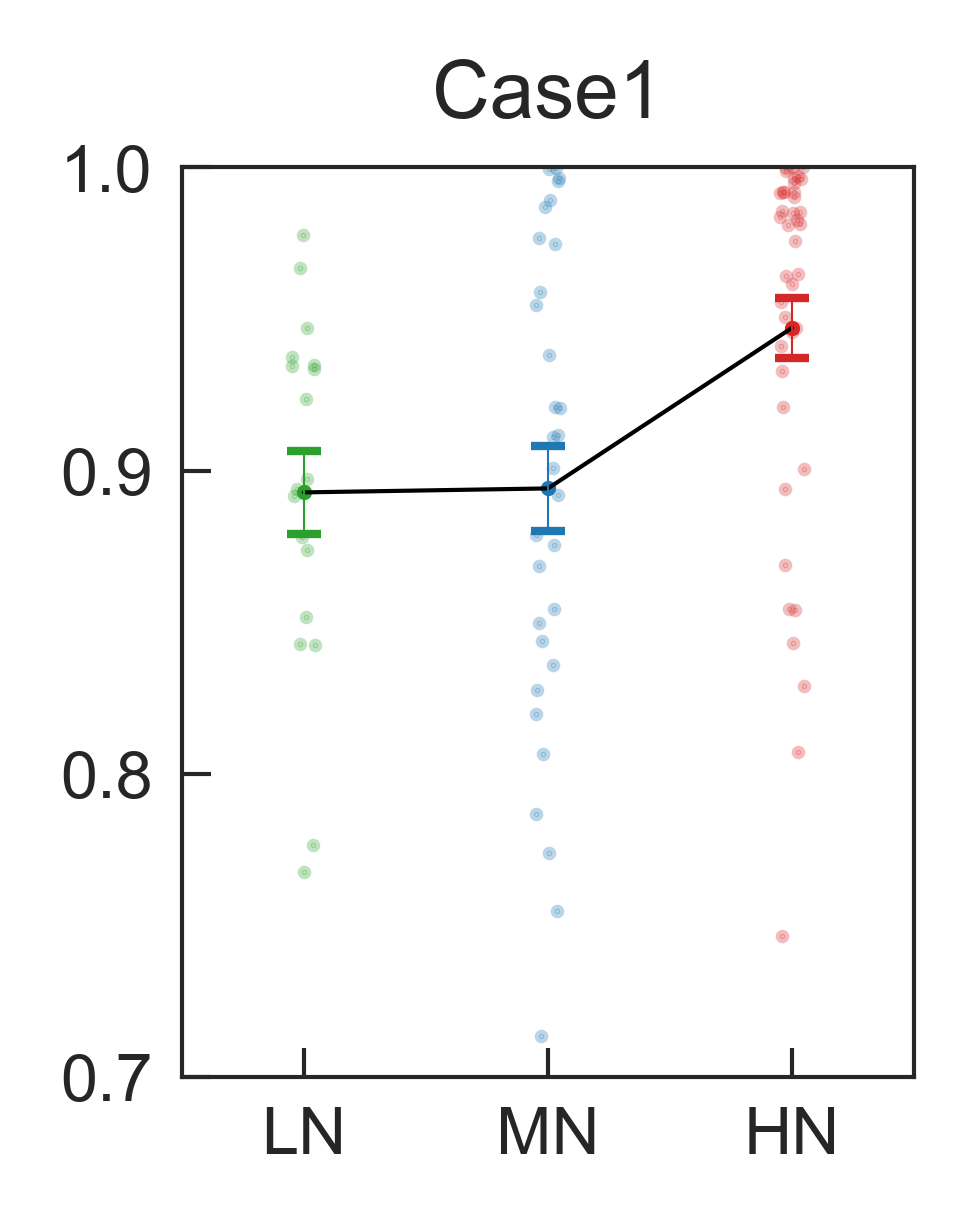

In [ ]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

    
data={}
data2={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    data_i=[]
    data_j=[]
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        if ii==0:
            data_i.append(y)
            data_j.append(x)
        if ii==1:
            continue
        if ii==2:
            continue
    total_count=class1_count+class2_count+class3_count
    data[c_i]=data_i
    data2[c_i]=data_j
    

    
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=0

data=data2

x=[0,1,2]
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(3):
    if len(data[i])==0:
        continue
    random_component=(0.1*(np.random.rand(len(data[i]))-0.5))
    plt.scatter([x[i]]*len(data[i])+random_component, data[i], s=0.4, color= colors_points[i], alpha=0.3)
plt.plot(x, y,color='black', linewidth=0.5)
for i, c in enumerate(colors_points):
    plt.errorbar(x[i],y[i],yerr[i], linewidth=0.25, color=c, elinewidth=.25, capsize=2,capthick=1)
    plt.scatter(x[i],y[i],  linewidth=0.25, color=c, s=2.5)



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('y')
# Add custom x tick labels

plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0, 1, 2]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)

plt.xlim(-0.5, 2.5)
plt.ylim(0.7, 1)
plt.title('Case1')

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_case1_x.svg', bbox_inches='tight')


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


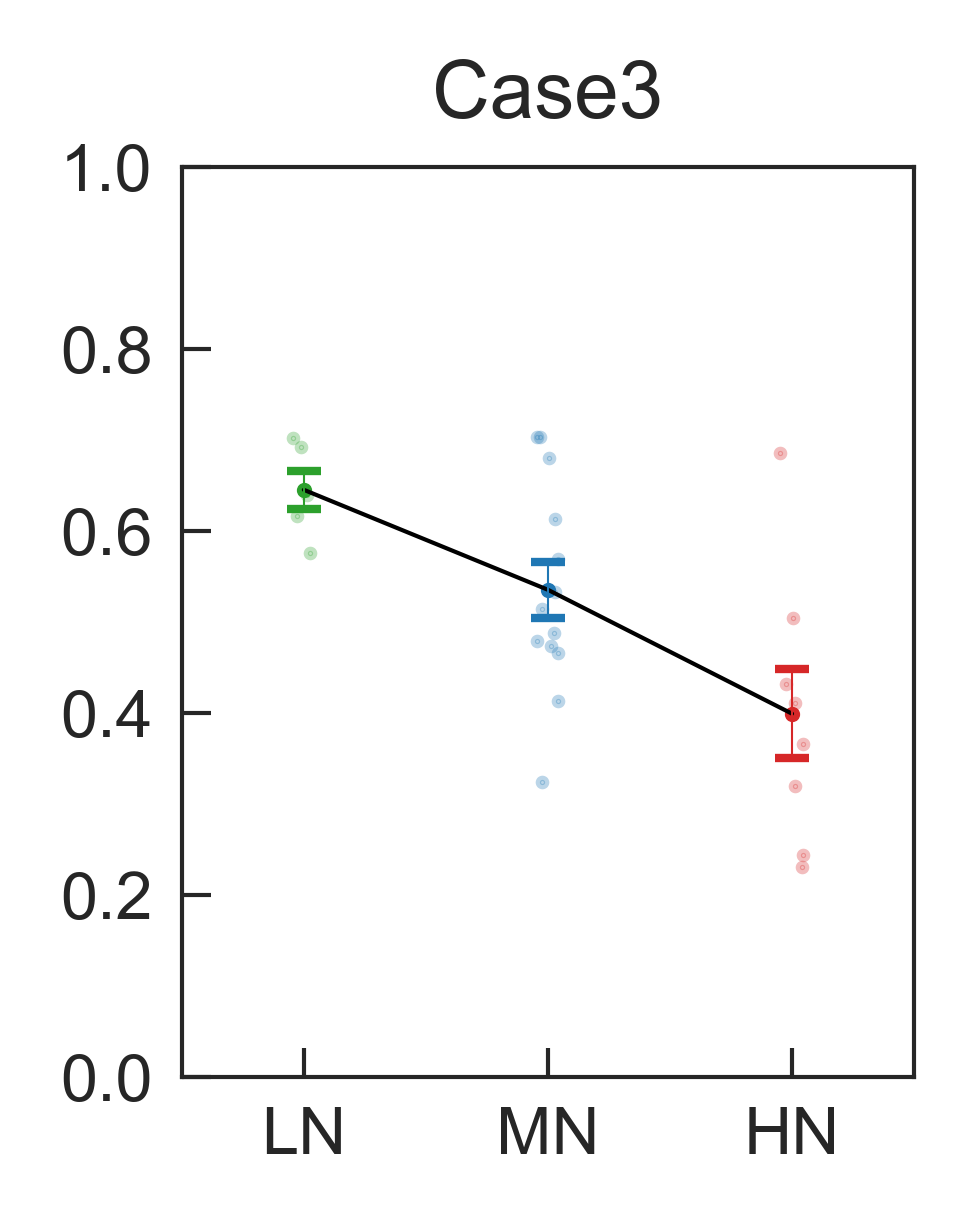

In [ ]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

    
data={}
data2={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    data_i=[]
    data_j=[]
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        if ii==0:
            continue
        if ii==1:
            continue
        if ii==2:
            data_i.append(y)
            data_j.append(x)
    total_count=class1_count+class2_count+class3_count
    data[c_i]=data_i
    data2[c_i]=data_j
    

    
f, ax = plt.subplots(1, figsize=(40*mm,50*mm), facecolor='w', edgecolor='k')
fromN=0

data=data2

x=[0,1,2]
y=np.nan_to_num([np.mean(data[i]) for i in data.keys()])
yerr=np.nan_to_num([np.std(data[i])/np.sqrt(len(data[i])) for i in data.keys()])

for i in range(3):
    if len(data[i])==0:
        continue
    random_component=(0.1*(np.random.rand(len(data[i]))-0.5))
    plt.scatter([x[i]]*len(data[i])+random_component, data[i], s=0.4, color= colors_points[i], alpha=0.3)
plt.plot(x, y,color='black', linewidth=0.5)
for i, c in enumerate(colors_points):
    plt.errorbar(x[i],y[i],yerr[i], linewidth=0.25, color=c, elinewidth=.25, capsize=2,capthick=1)
    plt.scatter(x[i],y[i],  linewidth=0.25, color=c, s=2.5)



#plt.scatter(df.values, cmap='gist_gray', interpolation='nearest')

# Add a colorbar to show the scale of the heatmap

# Add labels and title

# Display the grid
#plt.grid(False)
#plt.xlabel('u')
#plt.ylabel('y')
# Add custom x tick labels

plt.xticks([])

# Add custom x tick labels
custom_x_ticks = [0, 1, 2]
custom_x_labels = ['LN', 'MN', 'HN']

plt.xticks(custom_x_ticks, custom_x_labels)

plt.xlim(-0.5, 2.5)
plt.ylim(0, 1)
plt.title('Case3')

# Display the plot
plt.show()
f.savefig('Figure/Fig_2-2_OnveVar_U_dependency_case3_x.svg', bbox_inches='tight')


In [ ]:
Metadata

,SampleIDX,IDX,Timepoint,CommunityOrigin,Medium,CoalescenceType,Replicate,CommunityIDX,fieldOD1,fieldOD2,...,fieldPH1,fieldPH2,fieldPH3,fieldPH4,fieldPH5,fieldPH6,fieldPH7,fieldGC1,fieldGC2,fieldGC3
0,P1-01,101,F,S,L,S,1,1,0.359300,0.458264,...,7.6,7.6,7.6,7.6,7.6,7.6,7.6,1.071128,0.946439,1.026987
1,P1-02,102,F,S,L,S,1,2,0.390914,0.469201,...,7.6,7.6,7.6,7.6,7.8,7.8,7.8,0.919121,0.818128,0.846832
2,P1-03,103,F,S,L,S,1,3,0.433369,0.578633,...,7.6,7.6,7.6,7.6,7.6,7.6,7.6,0.623674,0.832236,0.720450
3,P1-04,104,F,S,L,S,1,4,0.464287,0.450153,...,7.5,7.4,7.4,7.4,7.6,7.6,7.6,0.873186,0.778548,0.877615
4,P1-05,105,F,S,L,S,1,5,0.395397,0.407637,...,7.6,7.6,7.6,7.6,7.6,7.6,7.6,0.895403,0.818128,0.910728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583,P7-36,736,F,N,H,C,2,11,1.117373,1.079741,...,9.0,8.9,9.1,9.0,9.1,9.0,9.0,0.587646,0.618873,0.670429
584,P7-48,748,F,N,H,C,2,12,0.253060,0.160336,...,4.6,5.4,4.0,4.0,3.9,4.2,4.1,0.335428,0.519063,0.254087
585,P7-60,760,F,N,H,C,2,13,1.116254,0.985119,...,8.8,9.0,8.0,8.9,8.9,9.1,8.9,0.538689,0.643625,0.618873
586,P7-72,772,F,N,H,C,2,14,0.409714,0.129091,...,4.2,4.0,3.9,3.9,3.8,3.9,3.9,0.308679,0.362978,0.247572


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


0 P4-41 15 16 220
0 P4-80 39 43 243
0 P4-82 39 41 241
0 P4-19 9 16 198
0 P4-78 39 46 245
1 P5-75 100 103 342
1 P5-35 72 77 308
1 P5-19 69 76 292
1 P5-23 70 74 296
1 P5-71 100 107 346
1 P5-25 70 76 298
1 P5-34 72 76 307
1 P5-70 101 103 347
1 P5-58 104 106 359
1 P5-72 100 106 345
1 P5-20 69 77 293
1 P5-74 100 104 343
1 P5-78 99 106 339
2 P6-78 159 166 433
2 P6-18 129 134 385
2 P6-58 164 166 453
2 P6-65 162 164 446
2 P6-23 130 134 390
2 P6-77 159 167 434
2 P6-79 159 164 432
2 P6-75 160 163 436


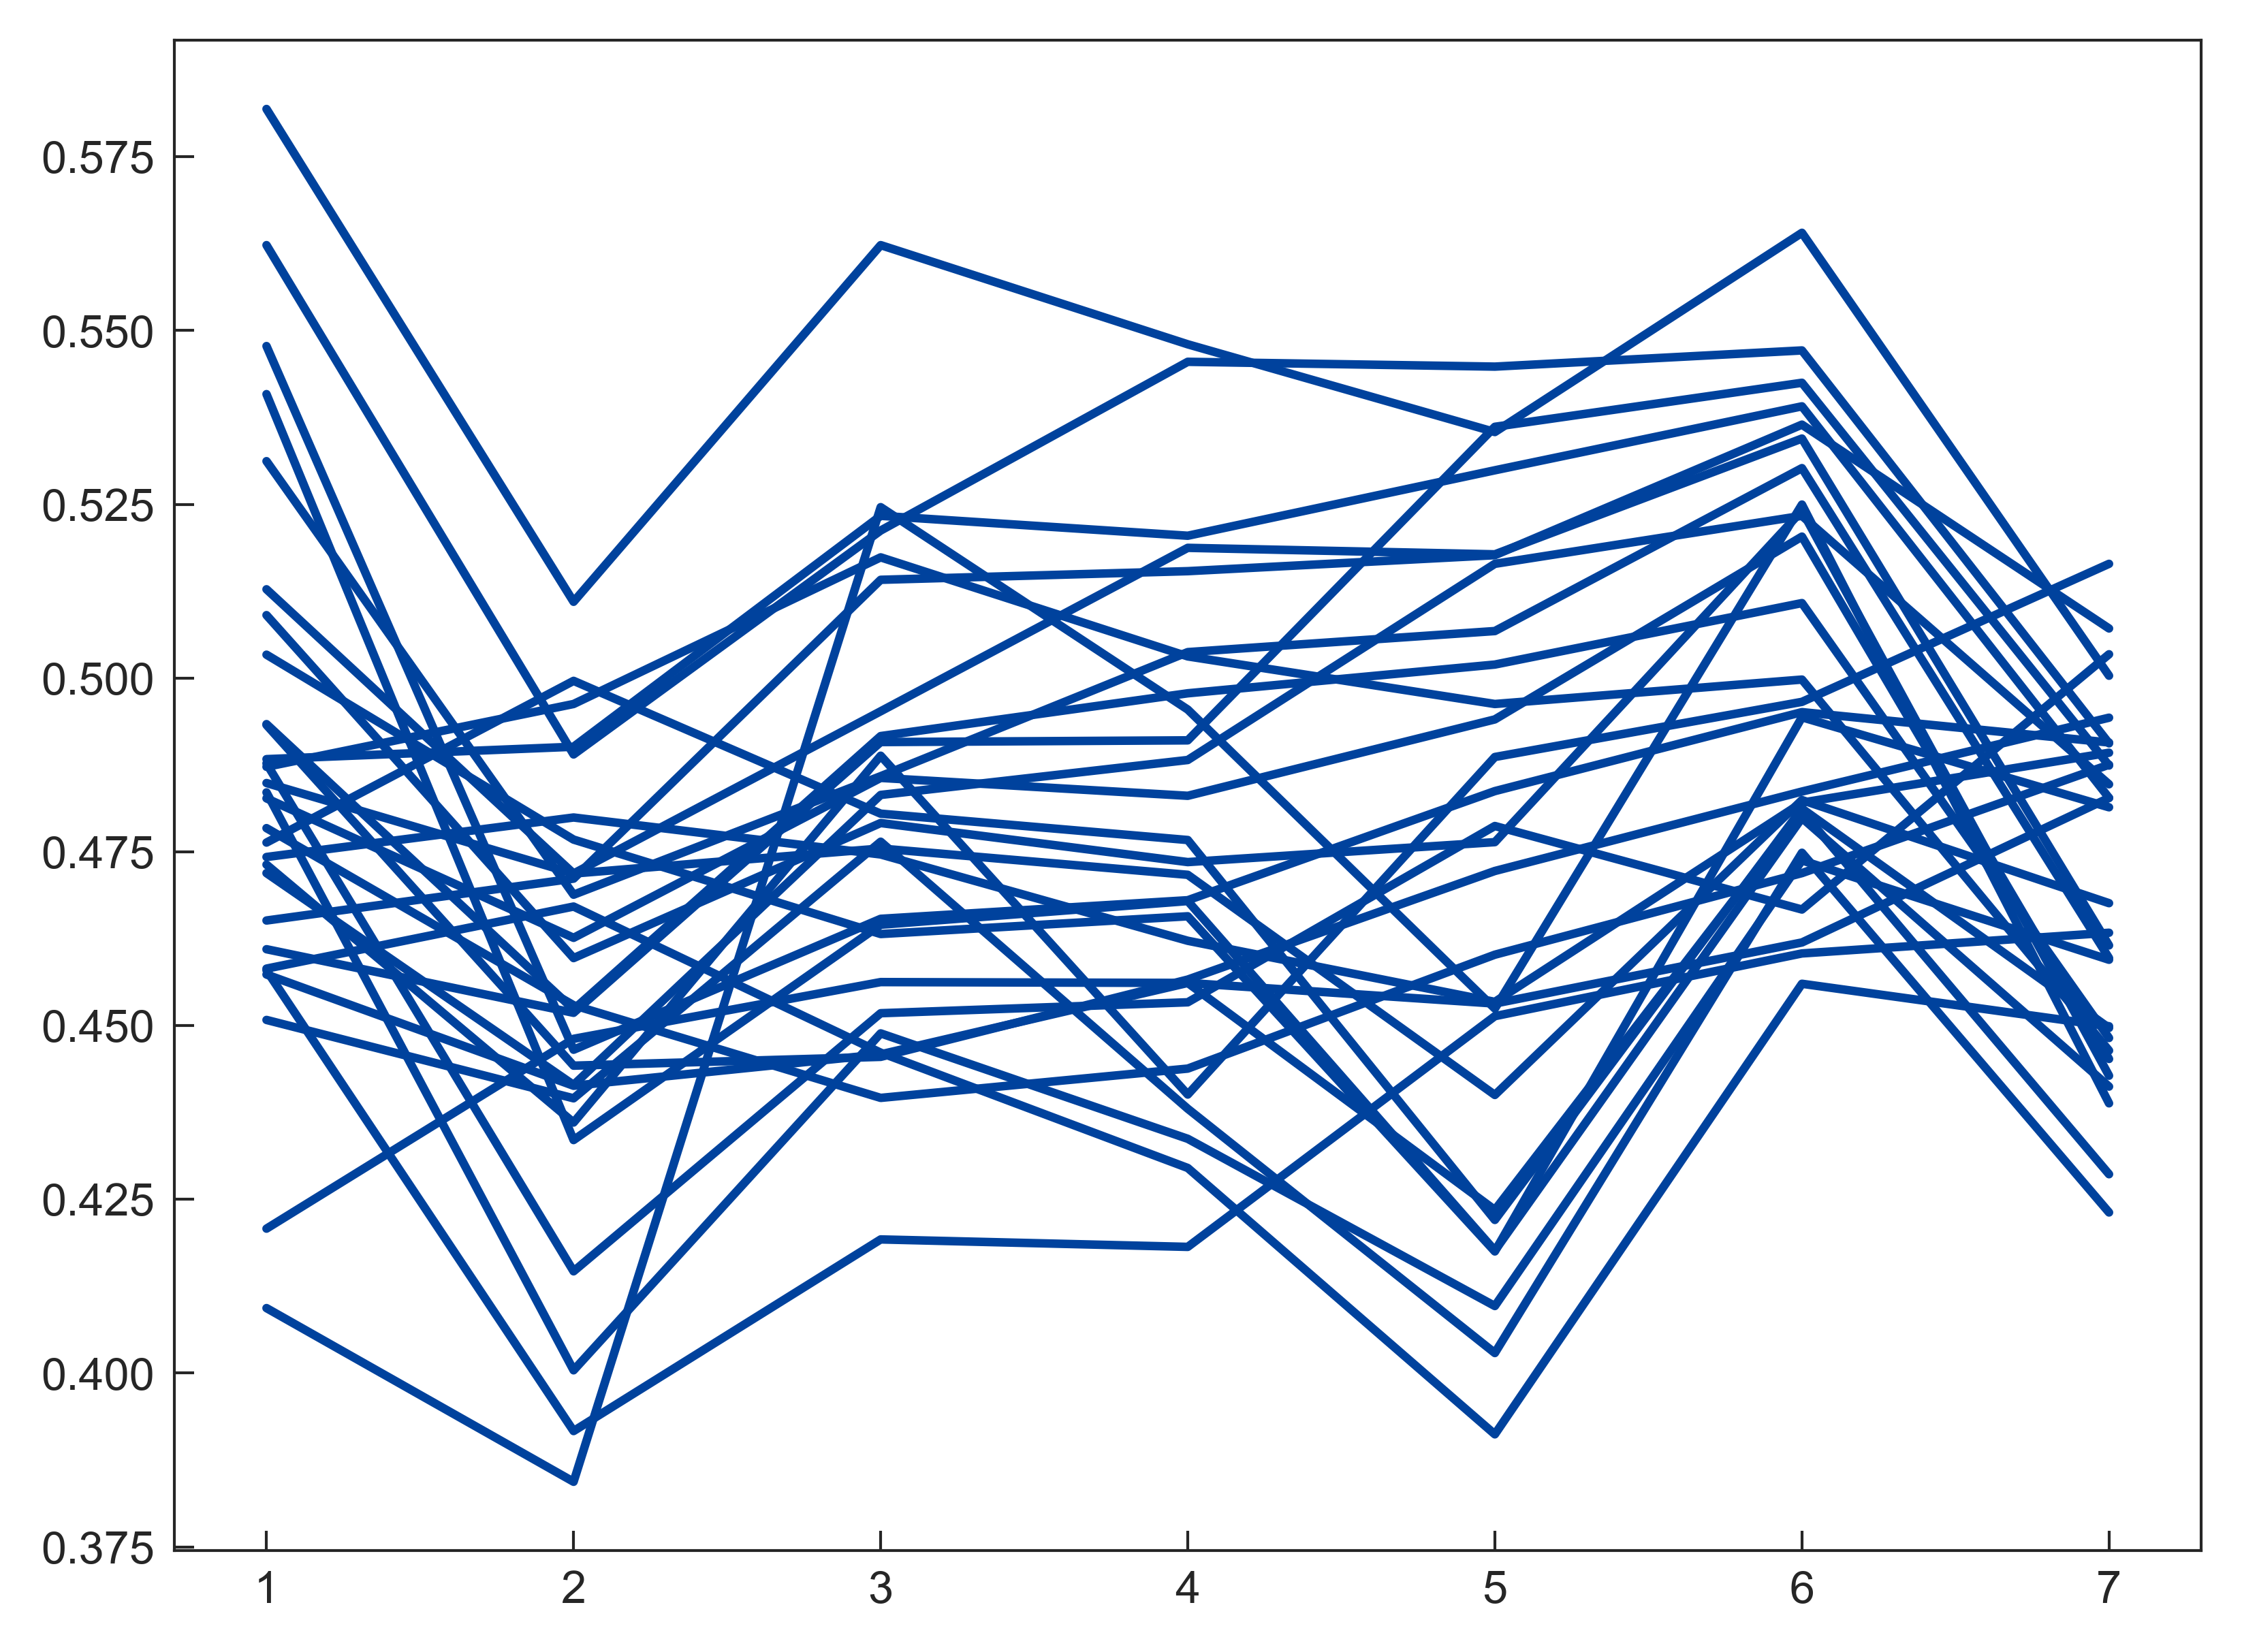

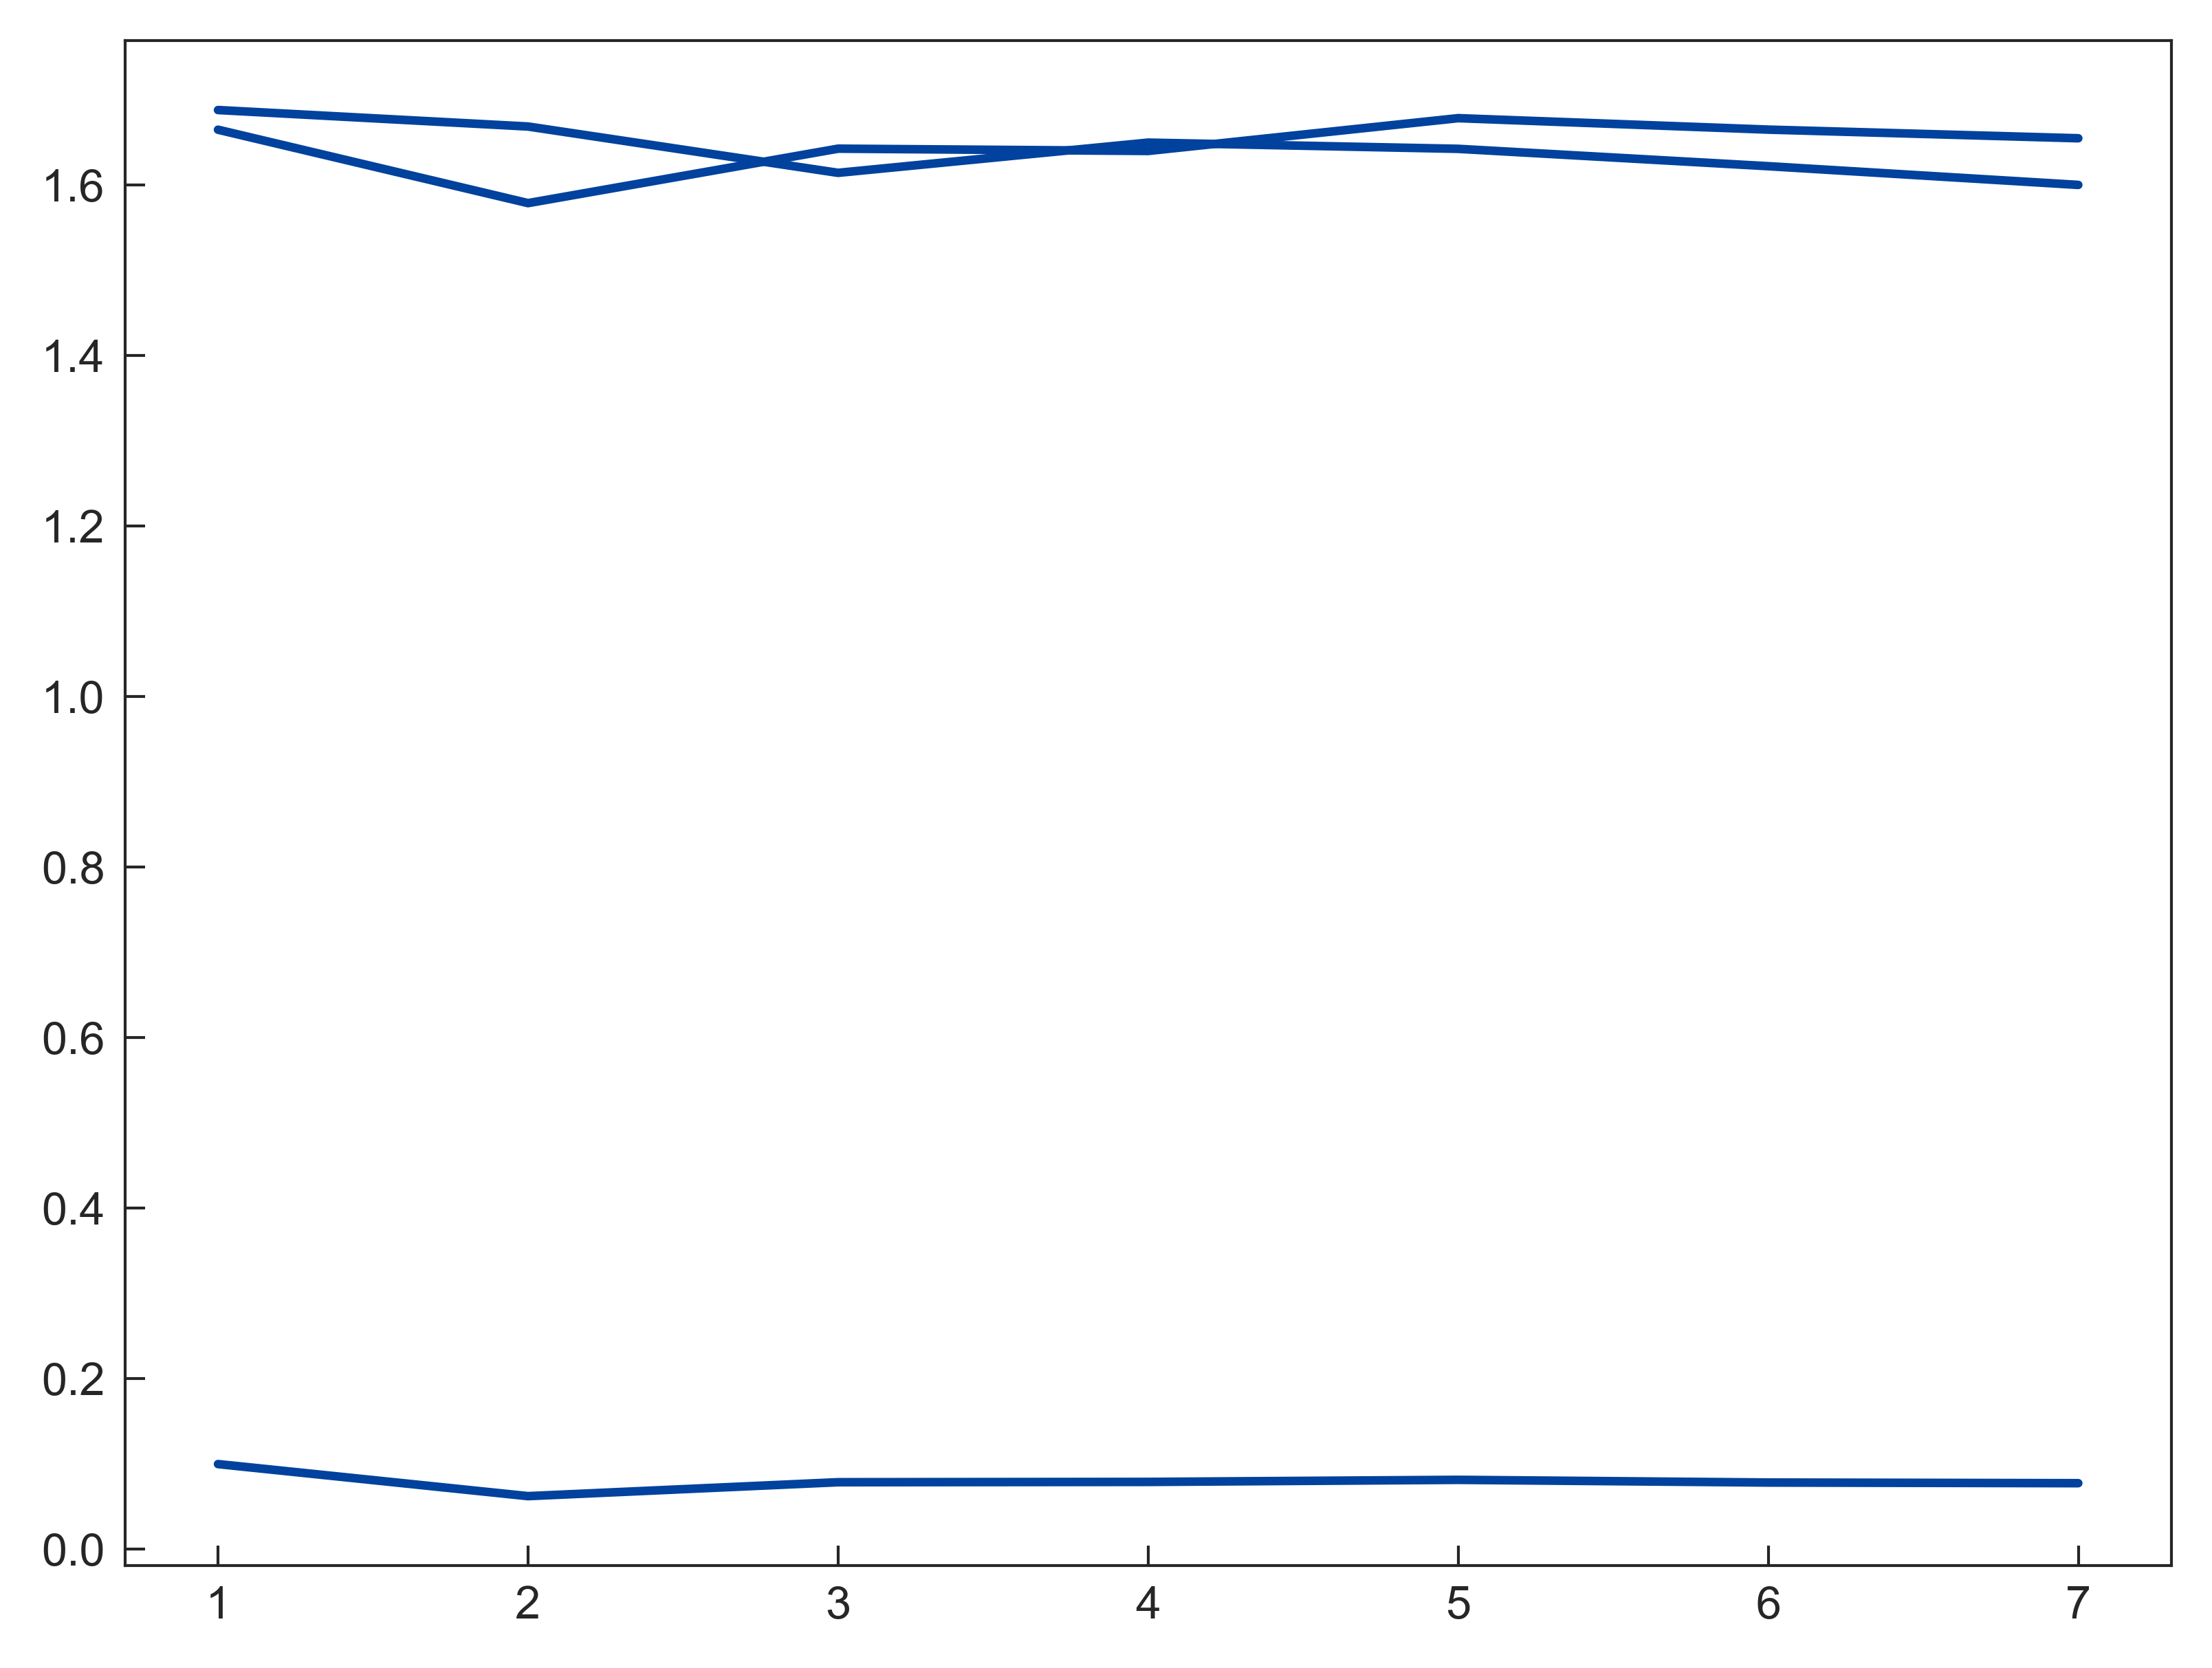

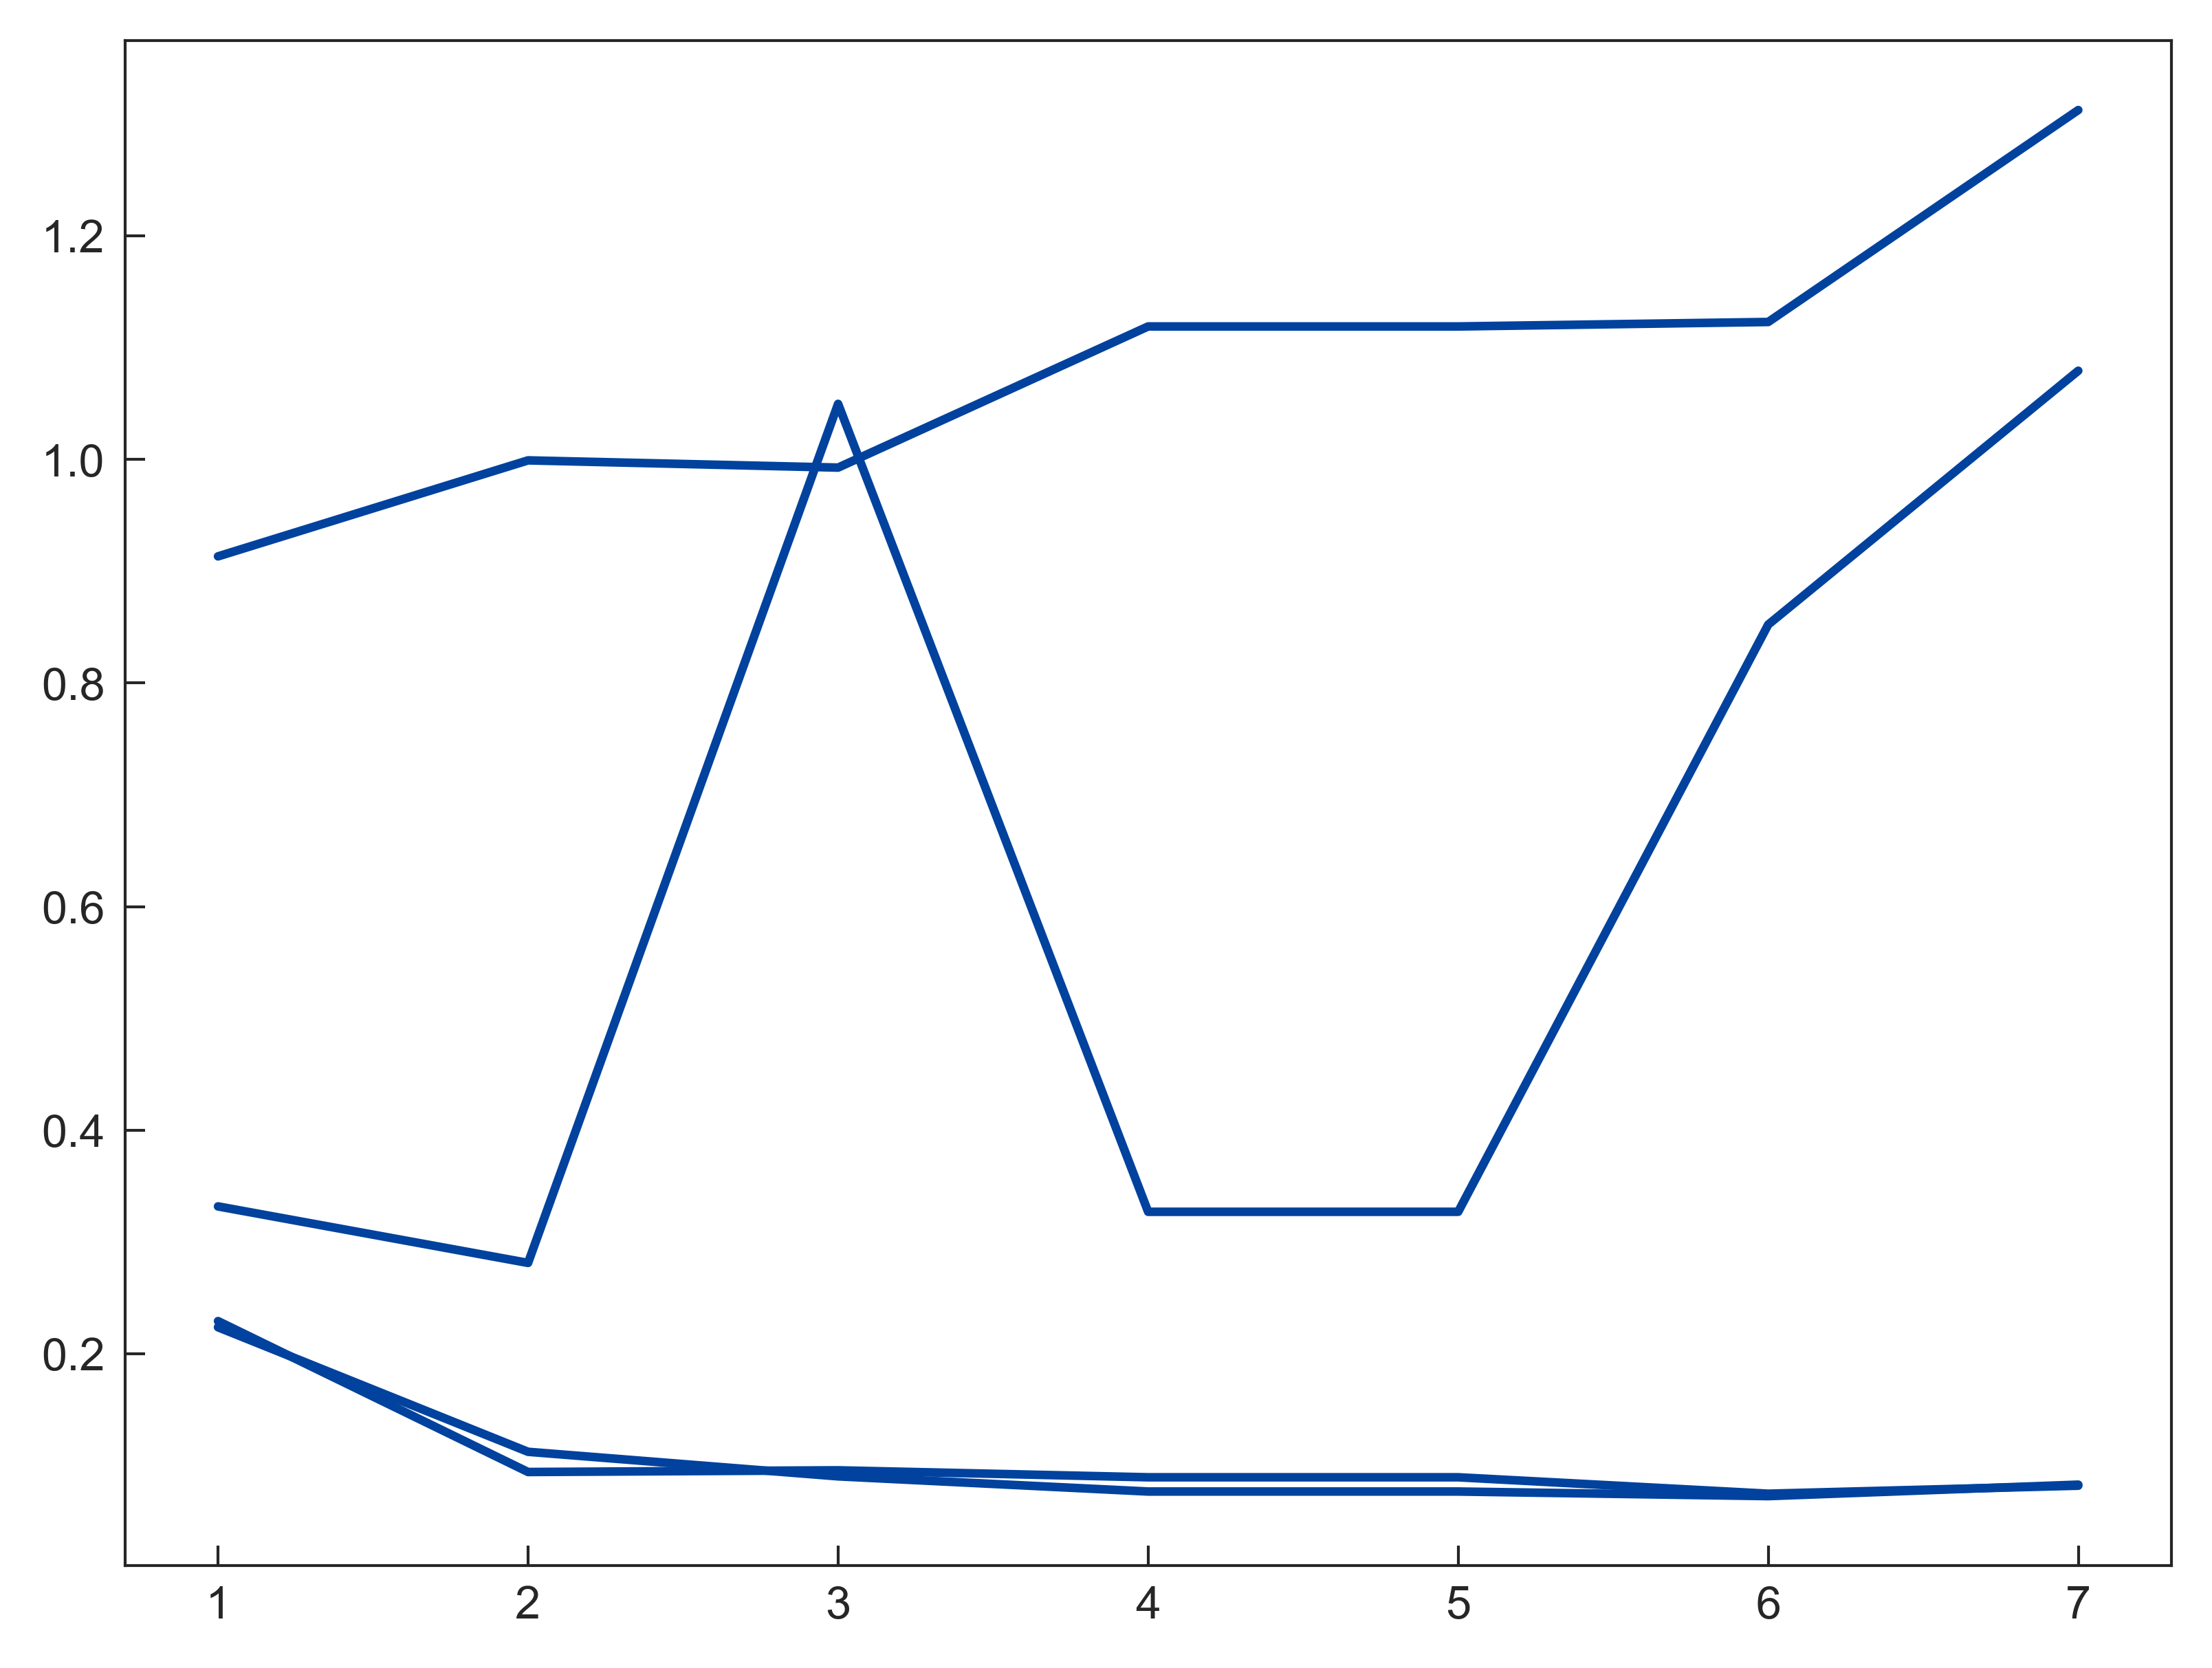

In [ ]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

    
label_data={}
OD_data={}
pH_data={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    data_label=[]
    OD=[]
    pH=[]
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in IDX_list])
    
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        data_label.append(ii)
        if ii==0:
            continue
        if ii==1:
            continue
        if ii==2:
            print(c_i,IDX_list[j], idx_1[j], idx_2[j], idx[j])
    
    OD = np.array([Metadata.iloc[idx][f'fieldOD{i}'] for i in range(1, 8)]).swapaxes(1,0)
    pH = np.array([Metadata.iloc[idx][f'fieldPH{i}'] for i in range(1, 8)]).swapaxes(1,0)
    label_data[c_i]=data_label
    OD_data[c_i]=OD
    pH_data[c_i]=pH

for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    OD=OD_data[c_i]
    pH=pH_data[c_i]
    label=label_data[c_i]
    plt.figure()
    for i in range(len(OD)):
        if label[i]==1:
            plt.plot(range(1,8), OD[i],color=colors[label[i]])

0 P4-41 15 16 220
0 P4-80 39 43 243
0 P4-82 39 41 241
0 P4-19 9 16 198
0 P4-78 39 46 245
1 P5-75 100 103 342
1 P5-35 72 77 308
1 P5-19 69 76 292
1 P5-23 70 74 296
1 P5-71 100 107 346
1 P5-25 70 76 298
1 P5-34 72 76 307
1 P5-70 101 103 347
1 P5-58 104 106 359
1 P5-72 100 106 345
1 P5-20 69 77 293
1 P5-74 100 104 343
1 P5-78 99 106 339
2 P6-78 159 166 433
2 P6-18 129 134 385
2 P6-58 164 166 453
2 P6-65 162 164 446
2 P6-23 130 134 390
2 P6-77 159 167 434
2 P6-79 159 164 432
2 P6-75 160 163 436


/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_80706/2568548652.py:30: RuntimeWarning: divide by zero encountered in divide
  y=np.abs(np.abs(np.arctan(np.array(u)/np.array(v)))-np.pi/4)/(np.pi/4)


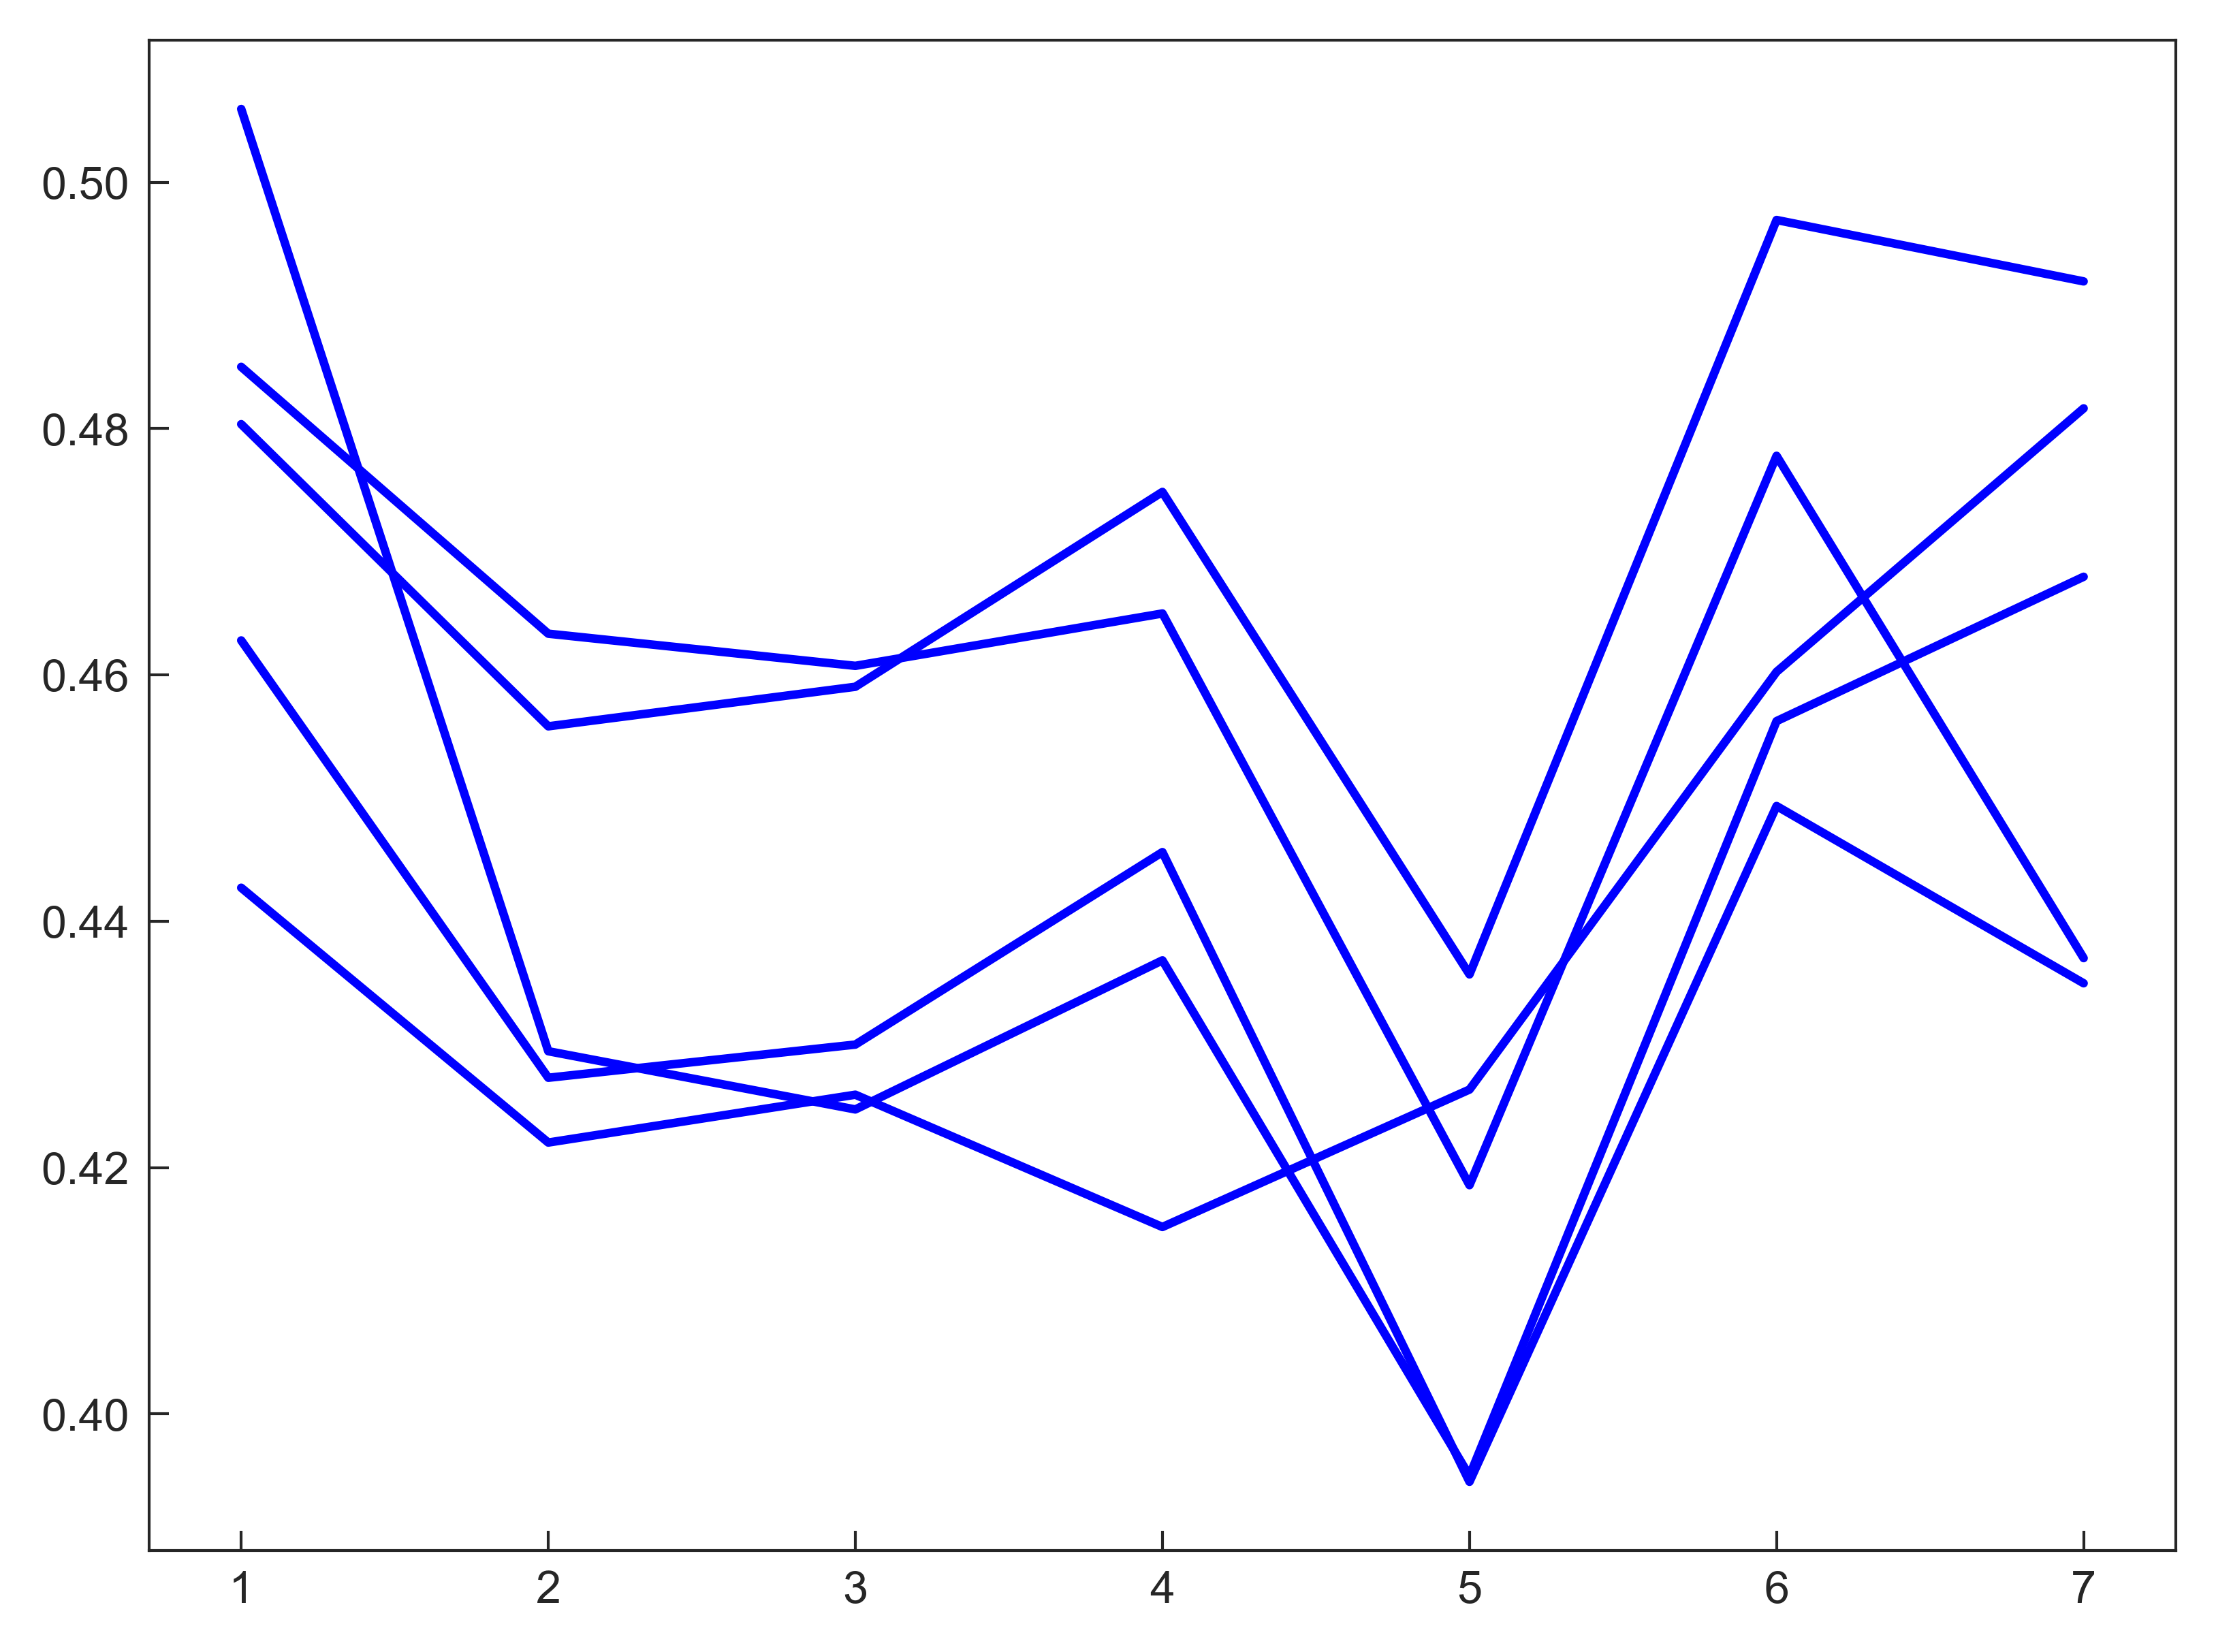

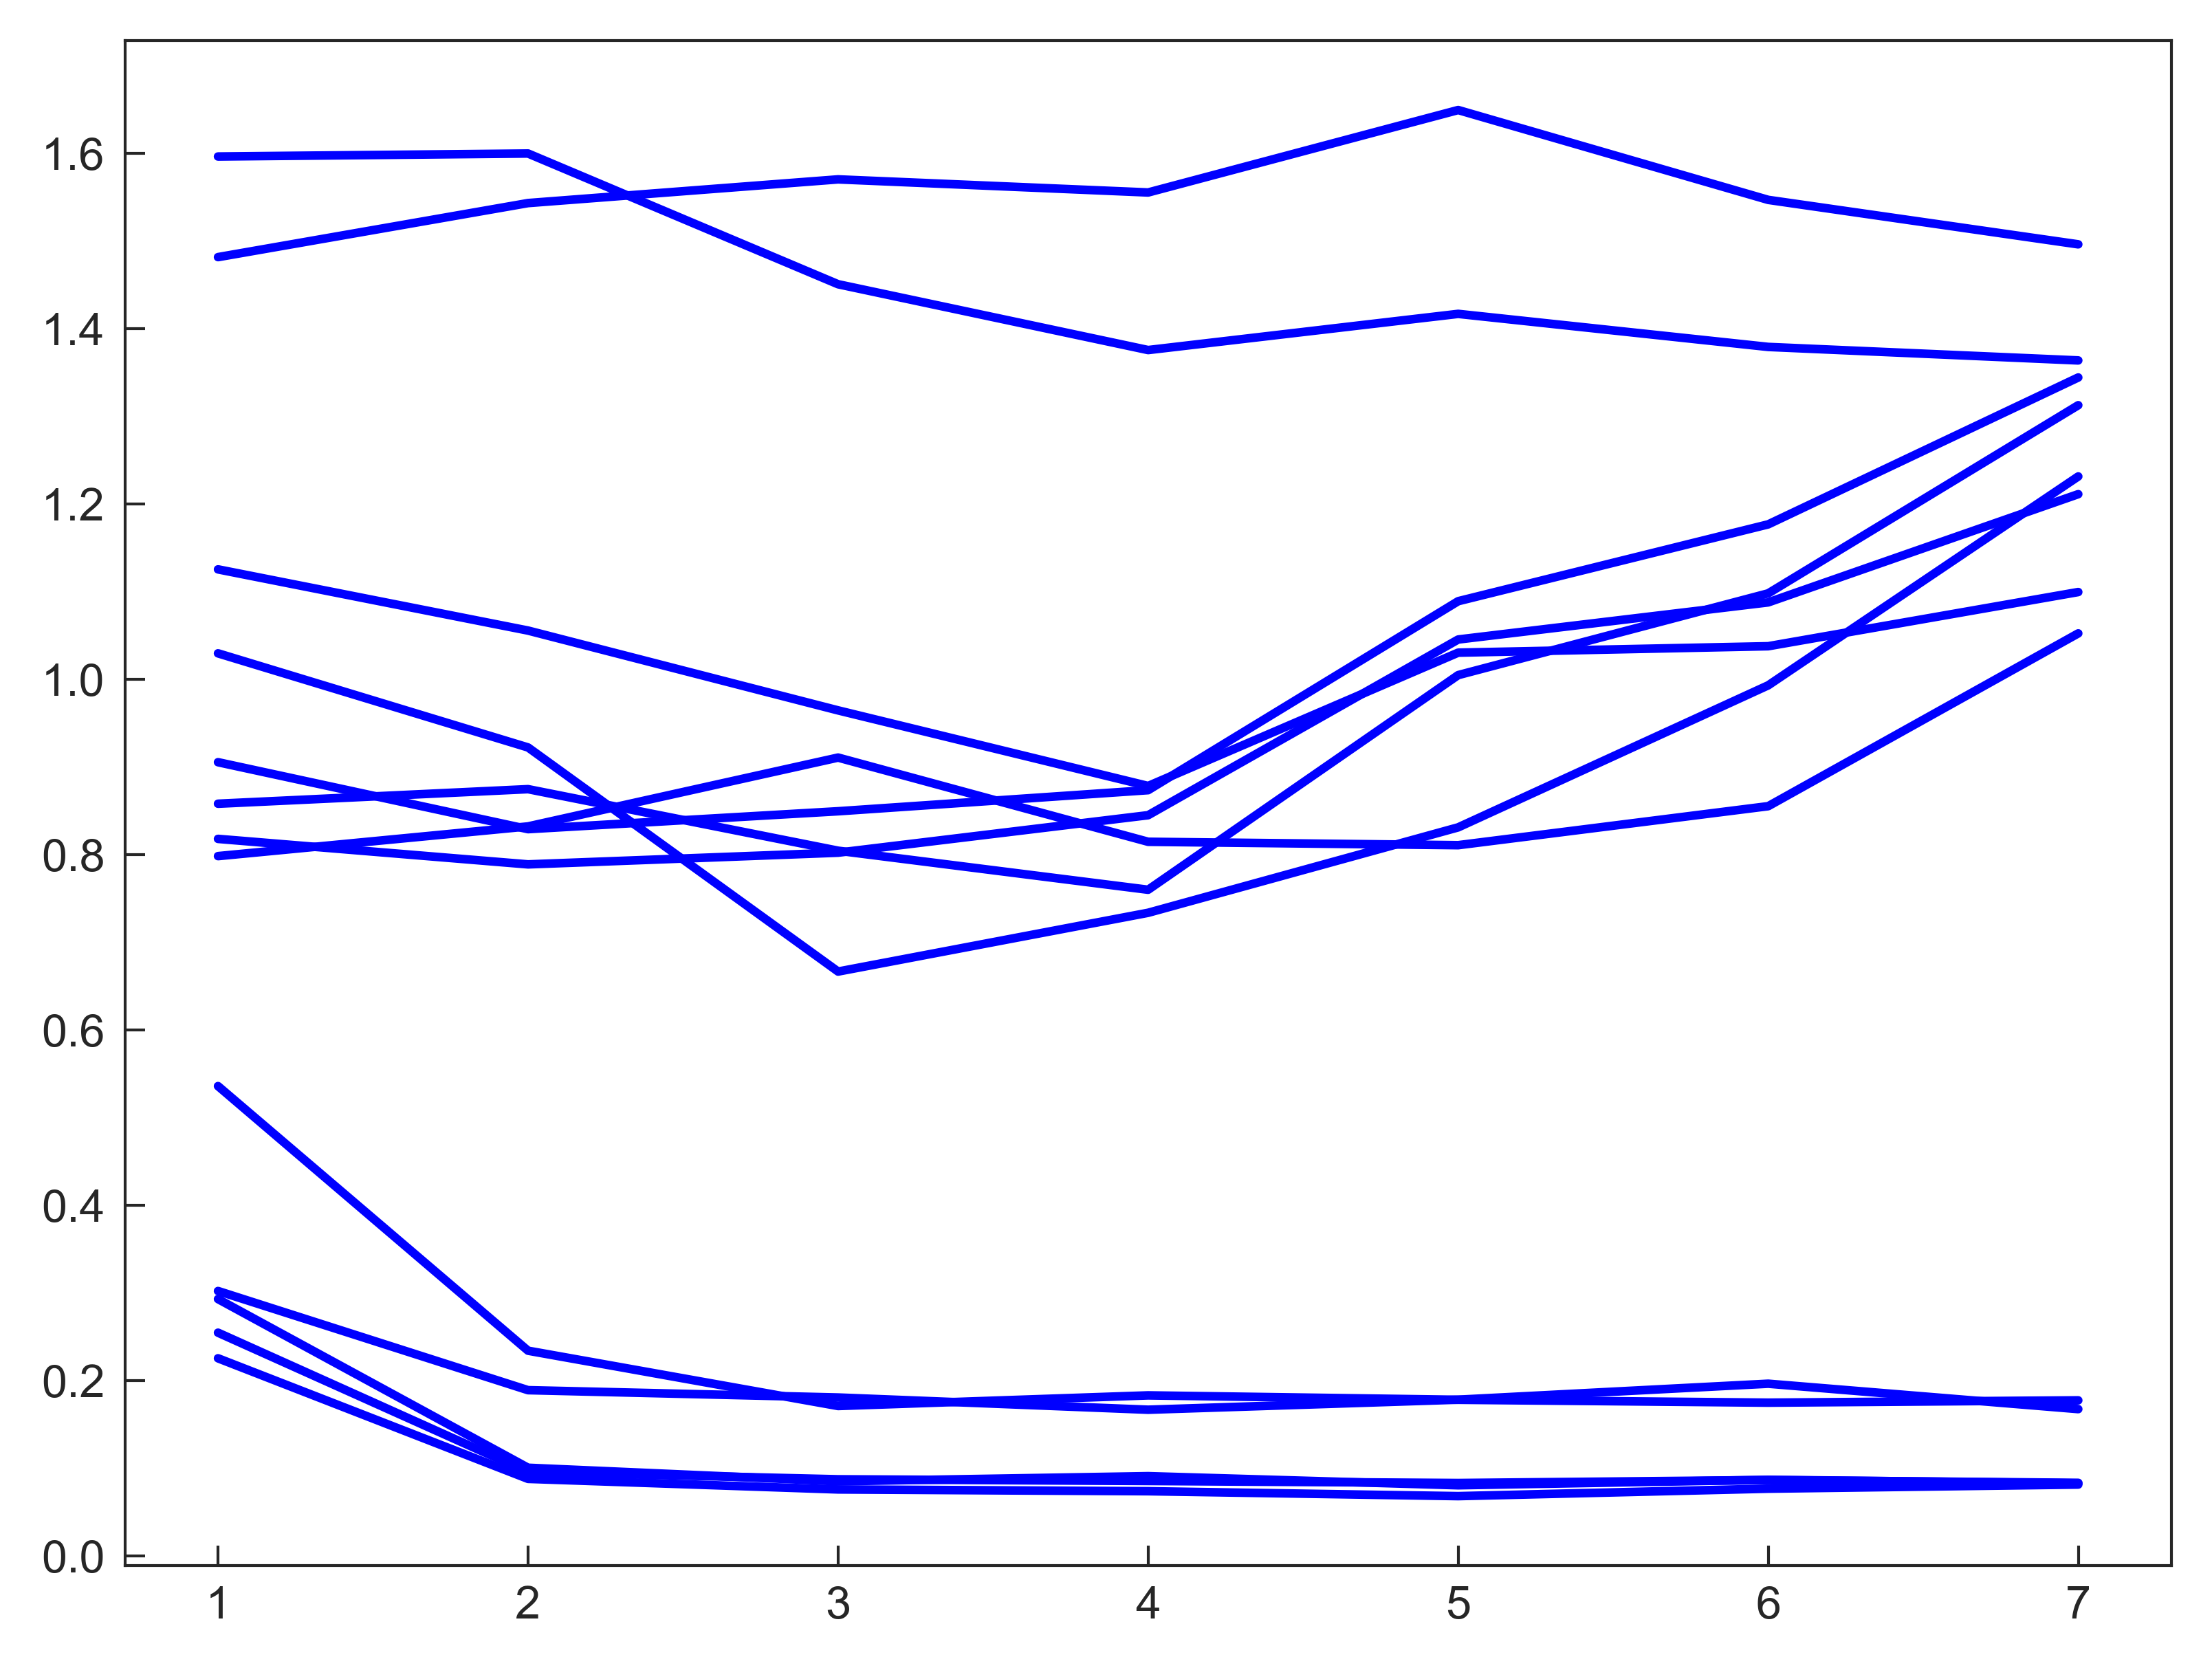

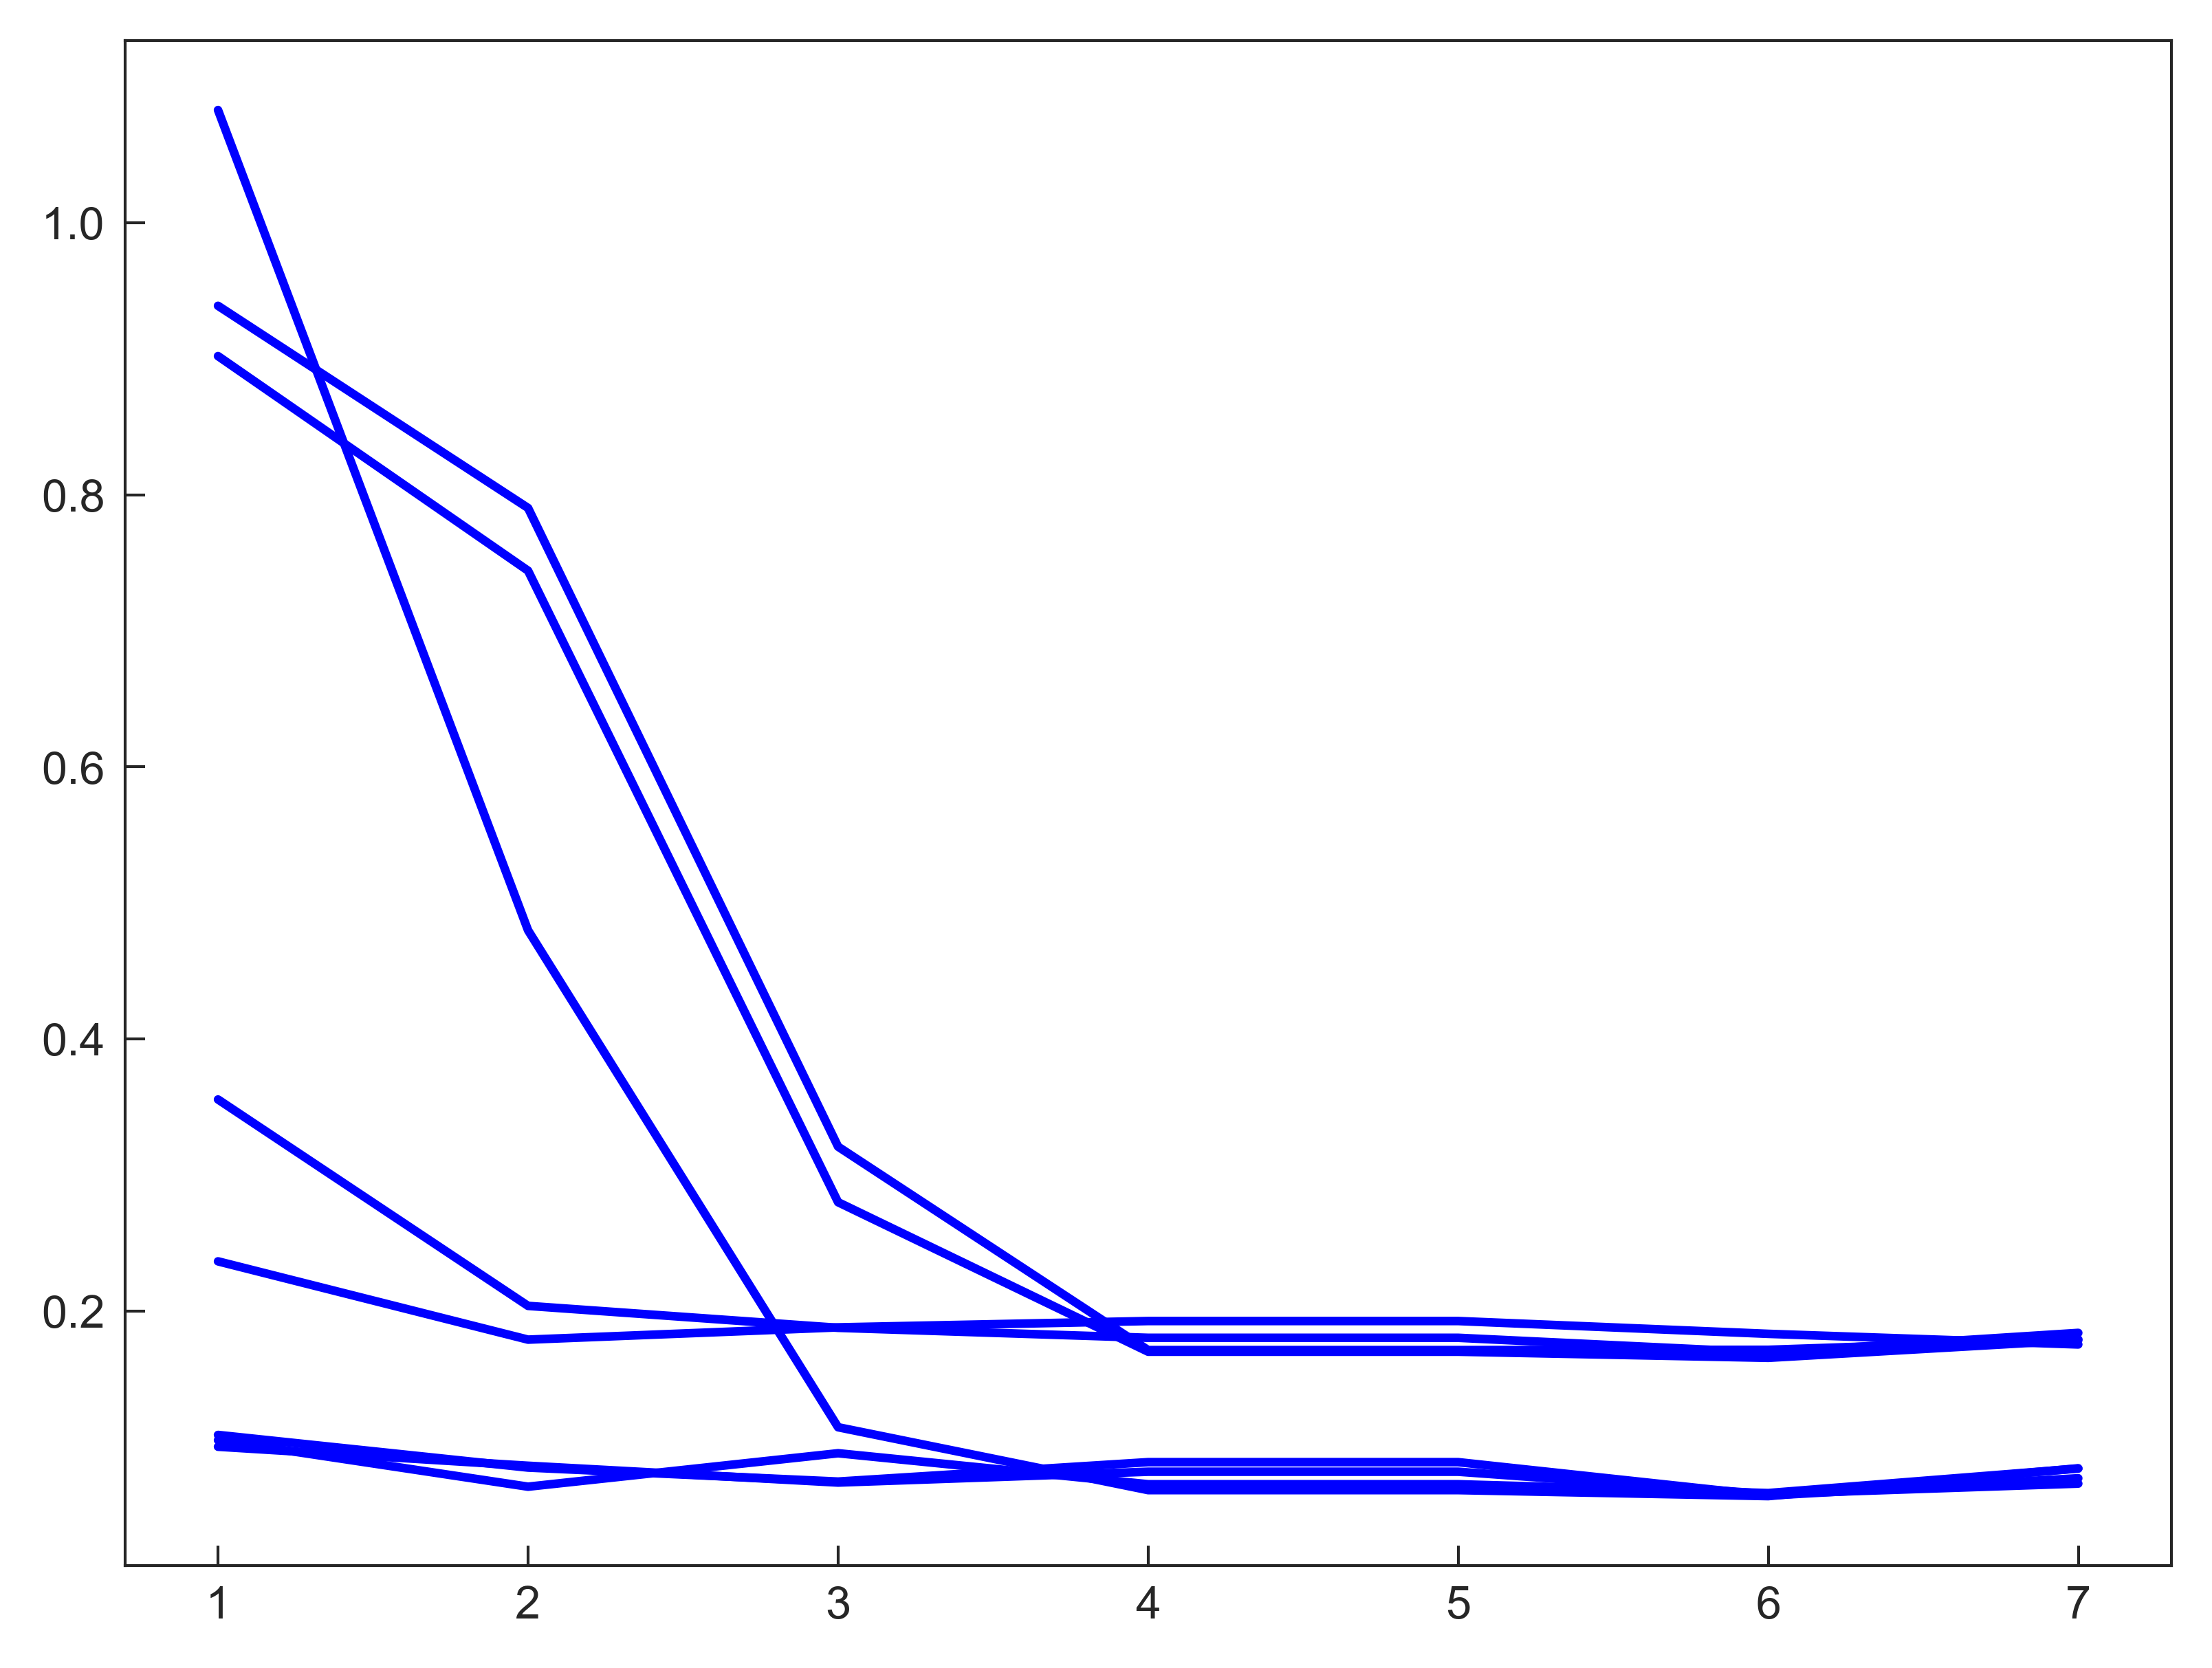

In [ ]:
colors=["grey", my_cmap(0), "blue"]
colors_points=([sns.color_palette("tab10")[2], sns.color_palette("tab10")[0], sns.color_palette("tab10")[3]])

    
label_data={}
OD_data={}
pH_data={}
OD1_data={}
pH1_data={}
OD2_data={}
pH2_data={}
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    data_label=[]
    OD=[]
    pH=[]
    IDX_list = Syn_Coal_IDX[type_name]
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
    idx_1=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in idx_1])
    idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
    idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
    idx_2=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in idx_2])
    idx=np.squeeze([np.where(Metadata['SampleIDX']==x) for x in IDX_list])
    
    for j in range(len(data1_set[type_name])):
        x,y=calculate_assymetricity(data1_set[type_name][j],data2_set[type_name][j],data3_set[type_name][j])
        ii=characterize_case(x,y)
        data_label.append(ii)
        if ii==0:
            continue
        if ii==1:
            continue
        if ii==2:
            print(c_i,IDX_list[j], idx_1[j], idx_2[j], idx[j])
    
    OD = np.array([Metadata.iloc[idx][f'fieldOD{i}'] for i in range(1, 8)]).swapaxes(1,0)
    pH = np.array([Metadata.iloc[idx][f'fieldPH{i}'] for i in range(1, 8)]).swapaxes(1,0)
    OD1 = np.array([Metadata.iloc[idx_1][f'fieldOD{i}'] for i in range(1, 8)]).swapaxes(1,0)
    pH1 = np.array([Metadata.iloc[idx_1][f'fieldPH{i}'] for i in range(1, 8)]).swapaxes(1,0)
    OD2 = np.array([Metadata.iloc[idx_2][f'fieldOD{i}'] for i in range(1, 8)]).swapaxes(1,0)
    pH2 = np.array([Metadata.iloc[idx_2][f'fieldPH{i}'] for i in range(1, 8)]).swapaxes(1,0)
    label_data[c_i]=data_label
    OD_data[c_i]=OD
    pH_data[c_i]=pH
    OD1_data[c_i]=OD1
    pH1_data[c_i]=pH1
    OD2_data[c_i]=OD2
    pH2_data[c_i]=pH2

for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    OD=OD_data[c_i]
    pH=pH_data[c_i]
    label=label_data[c_i]
    plt.figure()
    for i in range(len(OD)):
        if label[i]==2:
            plt.plot(range(1,8), OD[i],color=colors[label[i]])

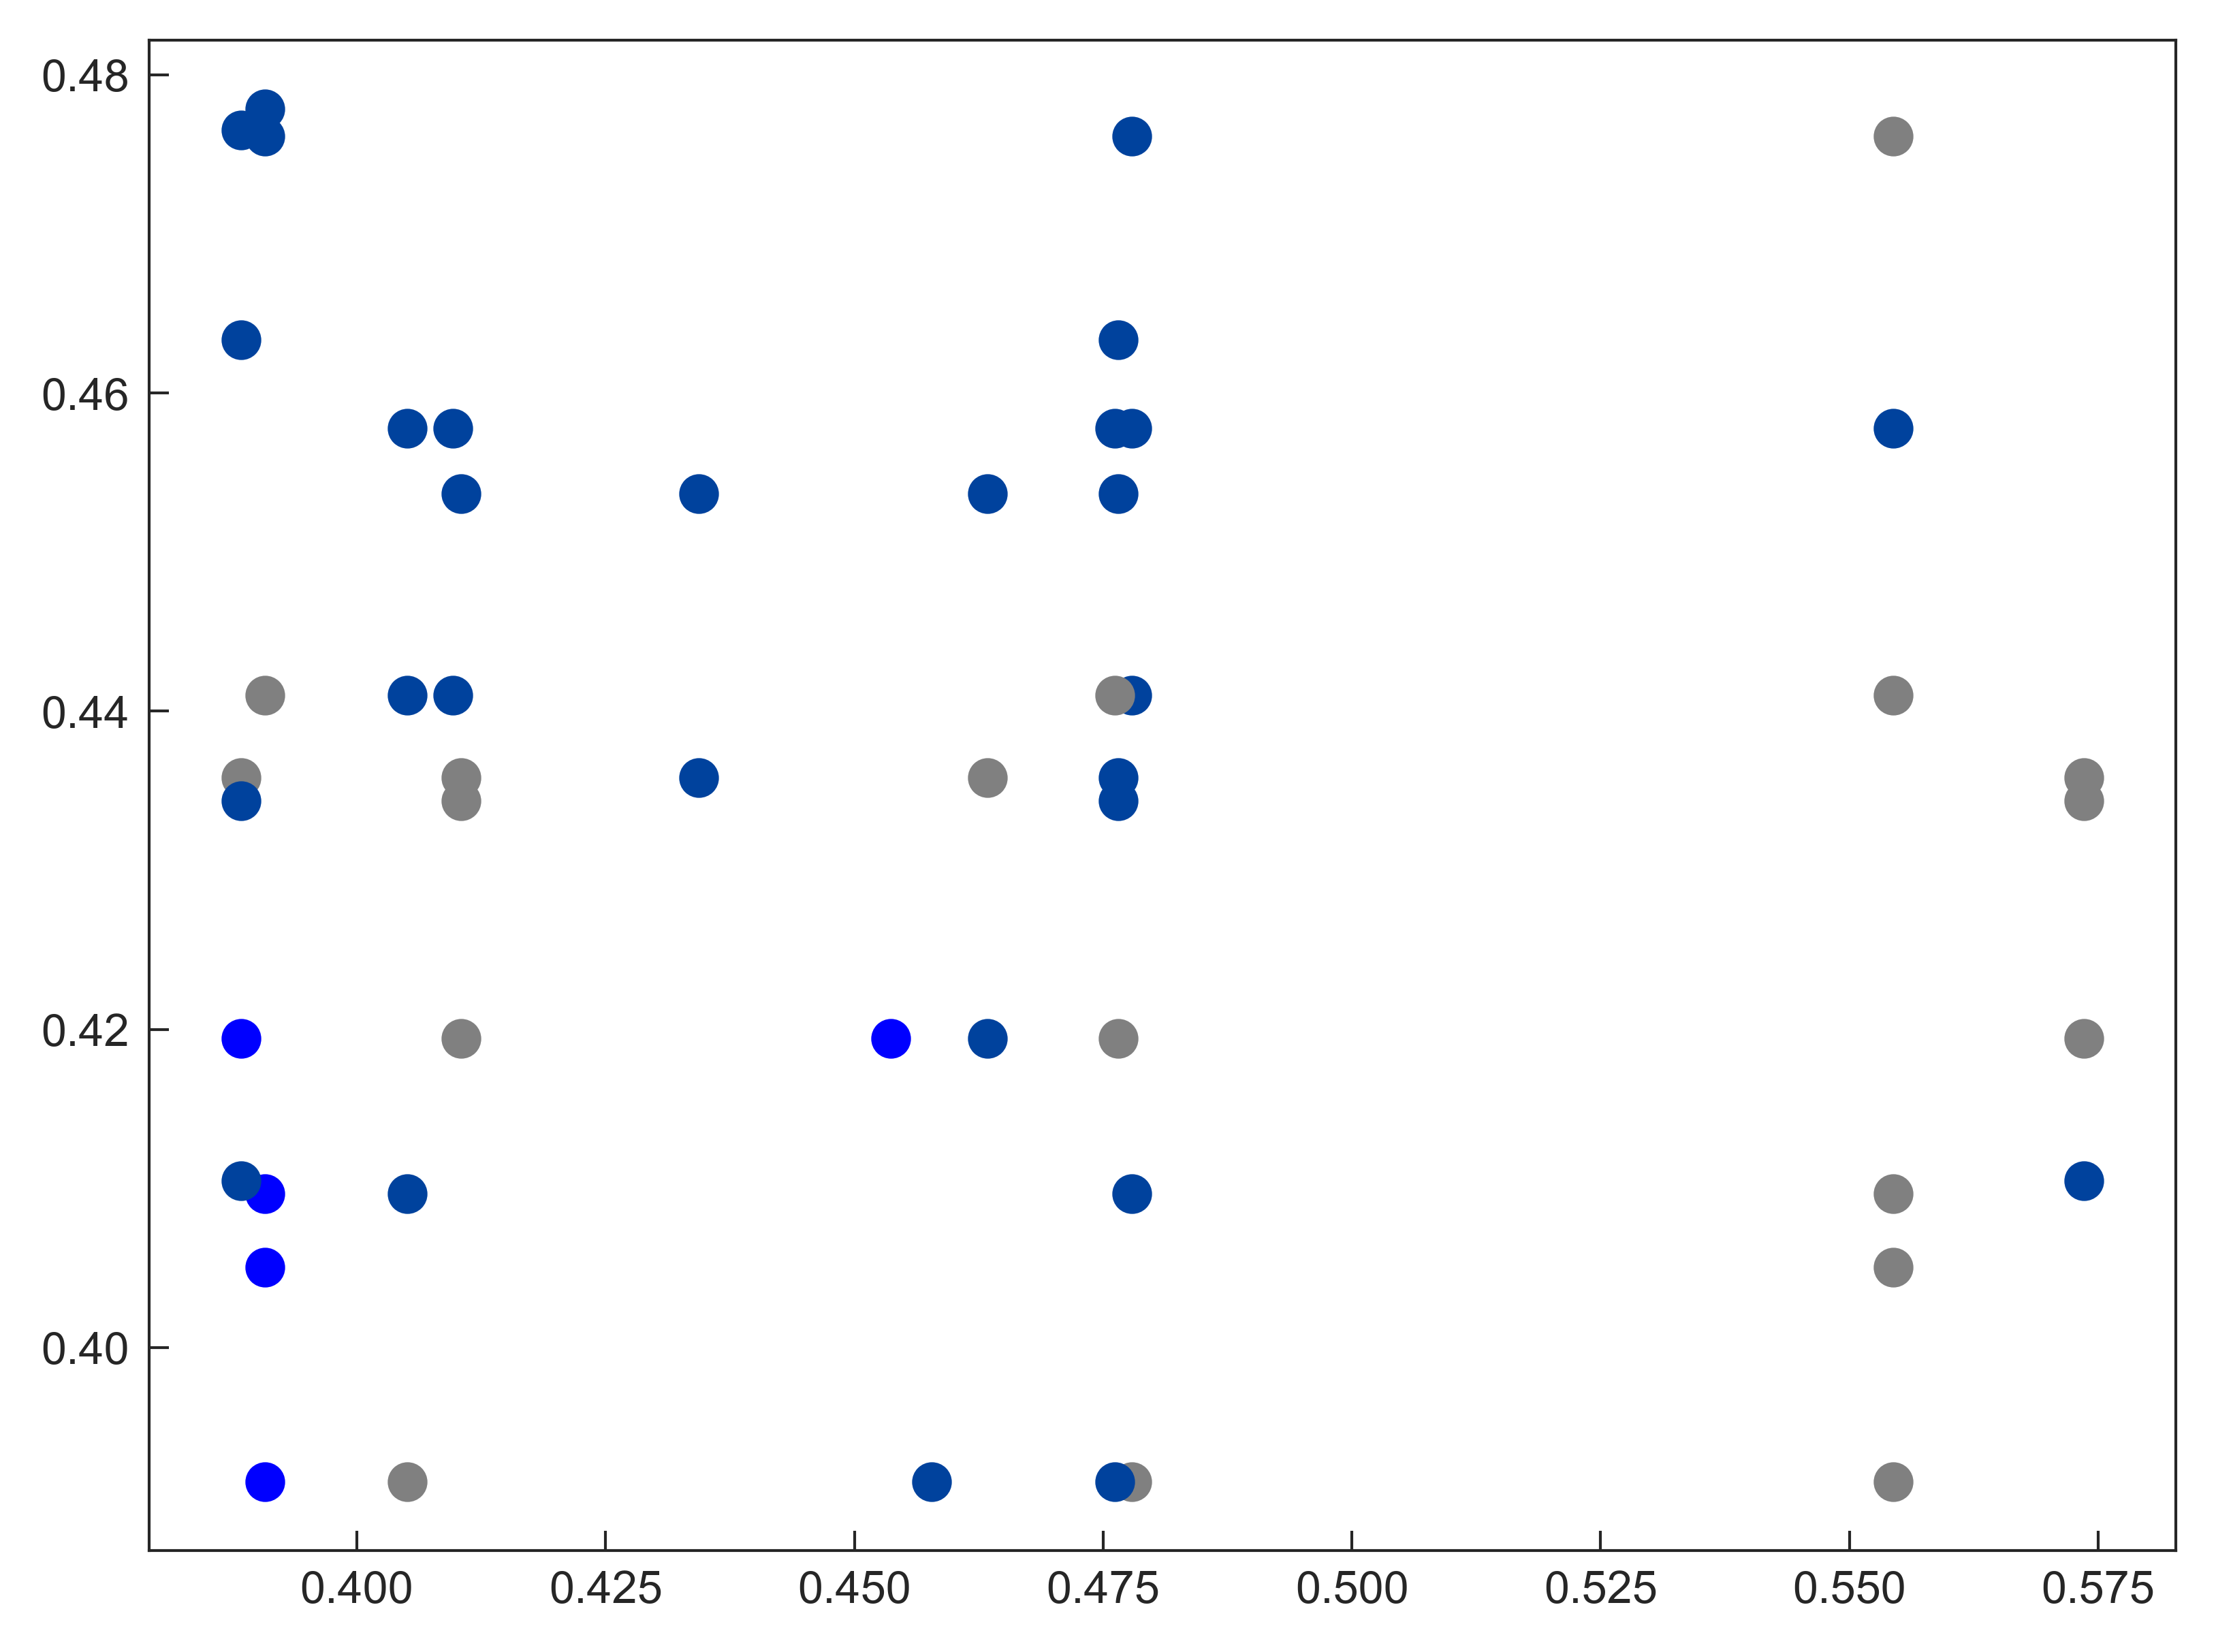

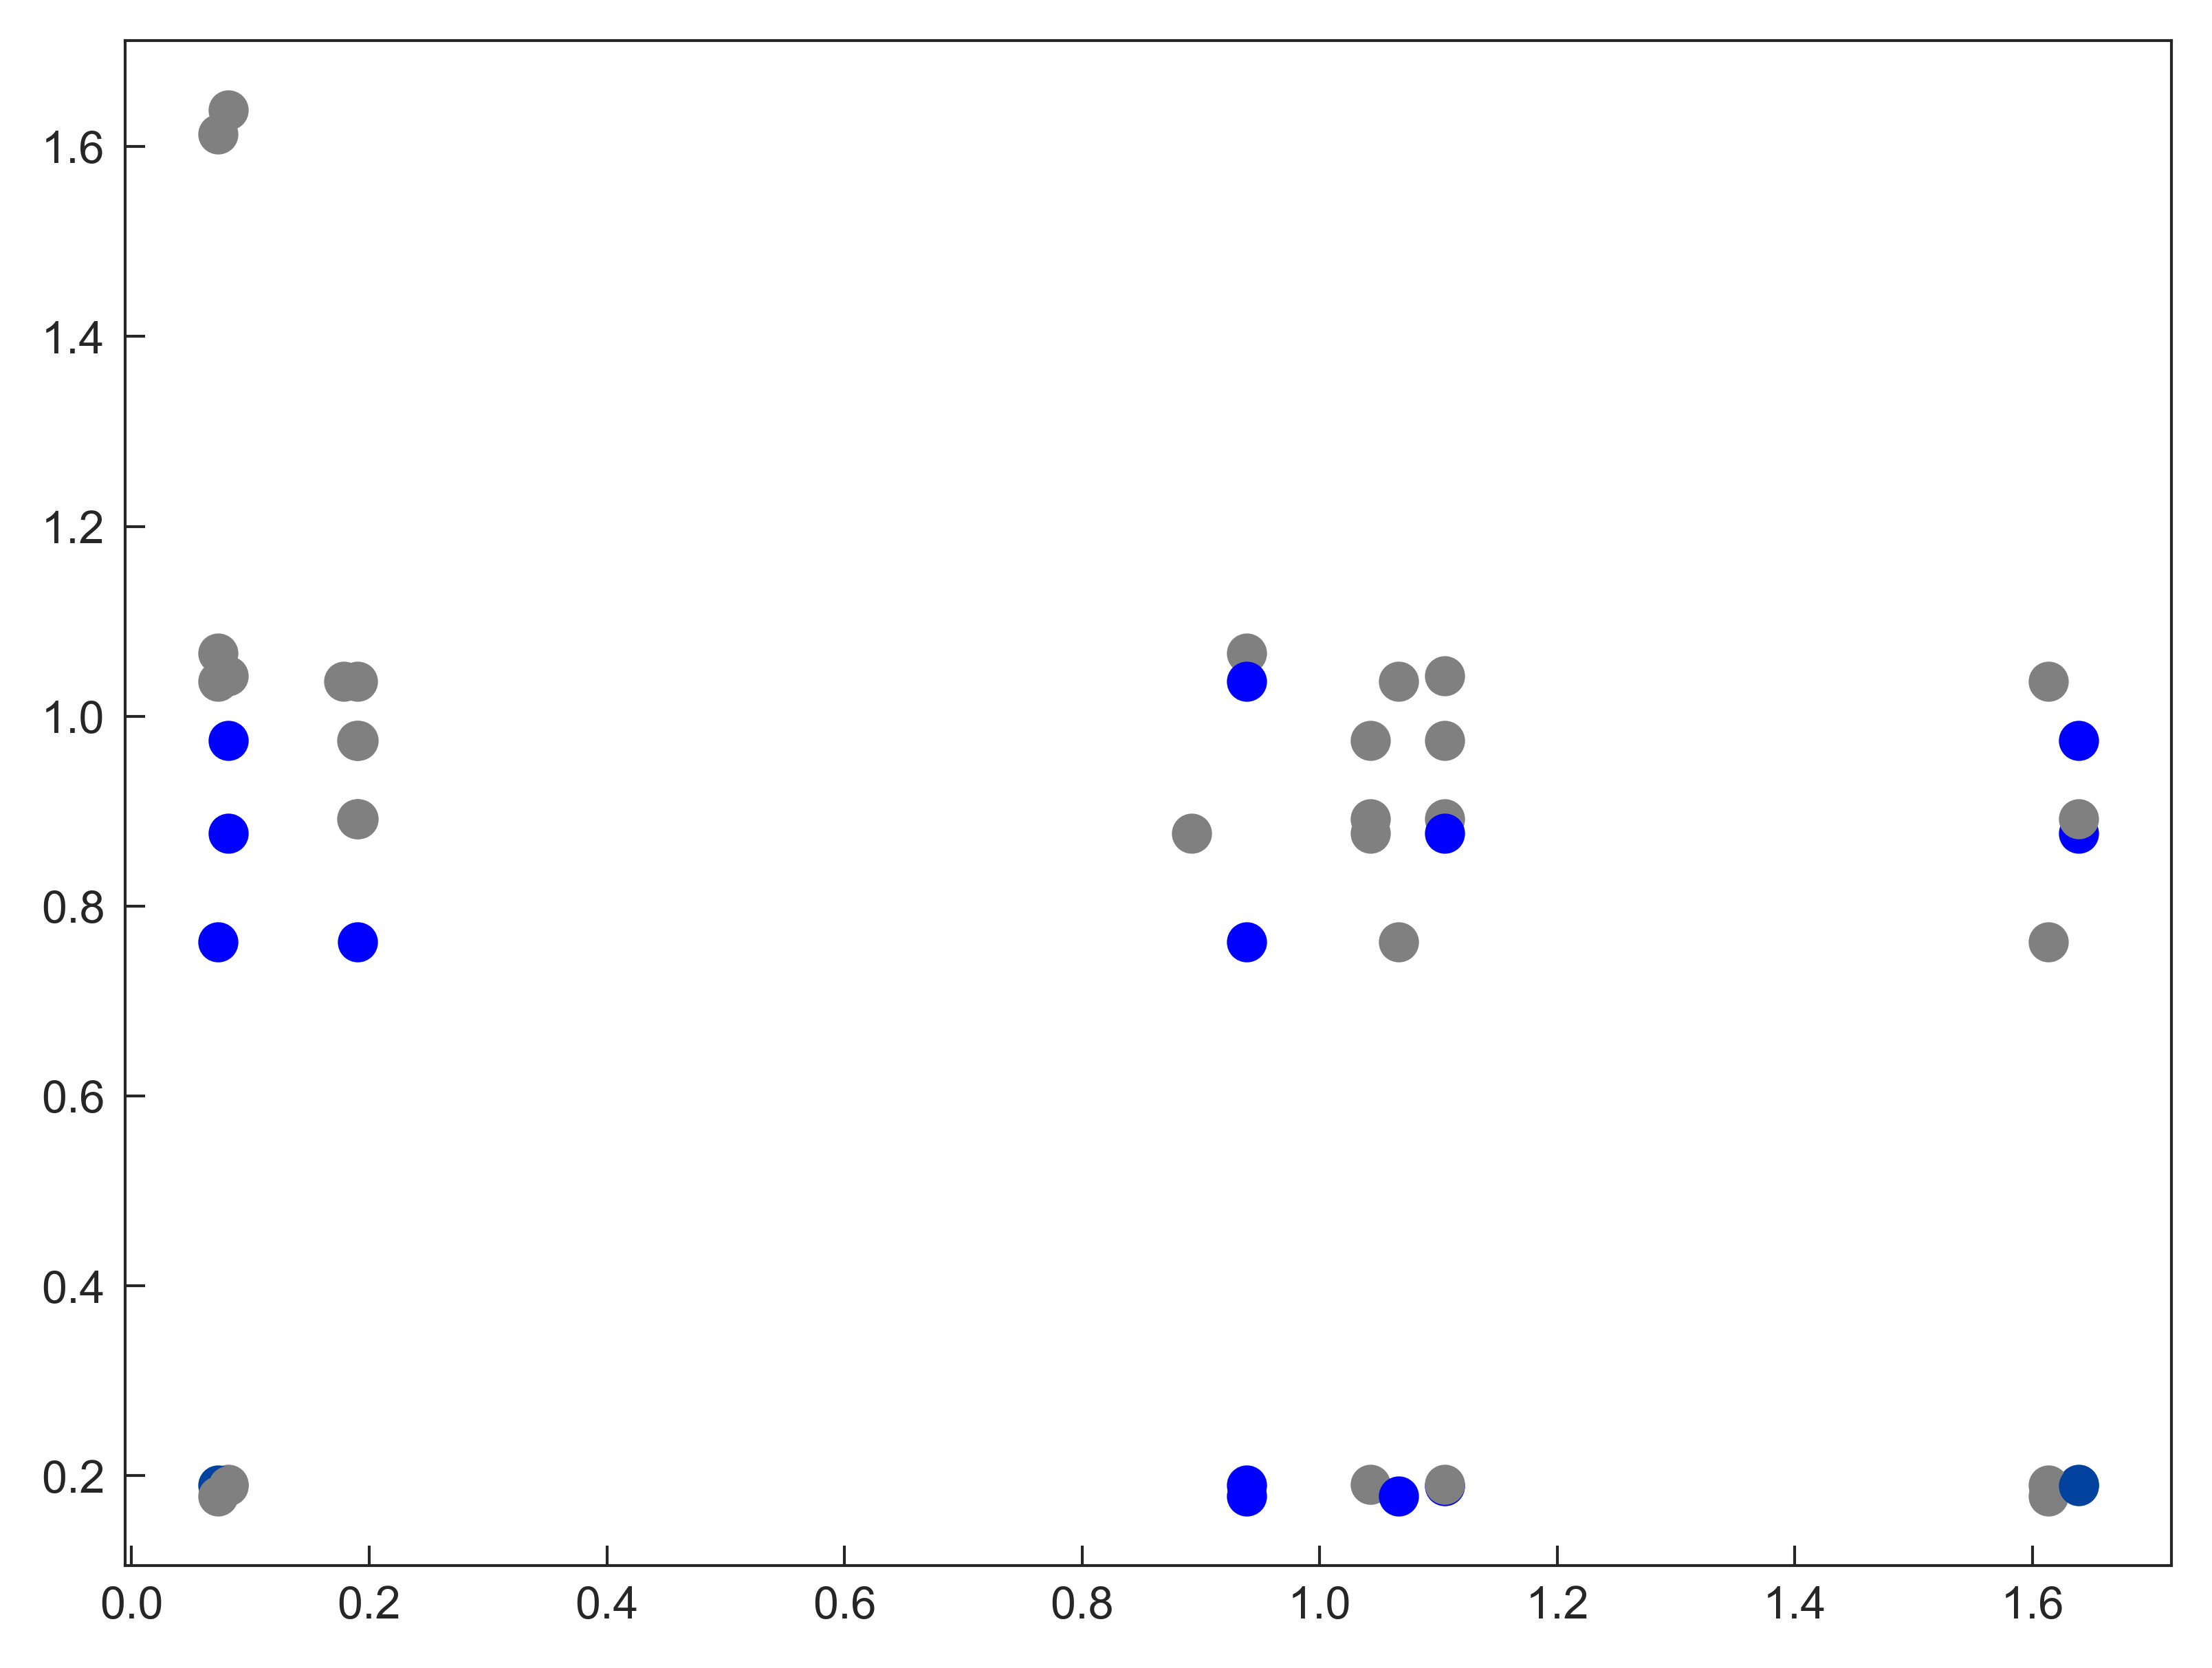

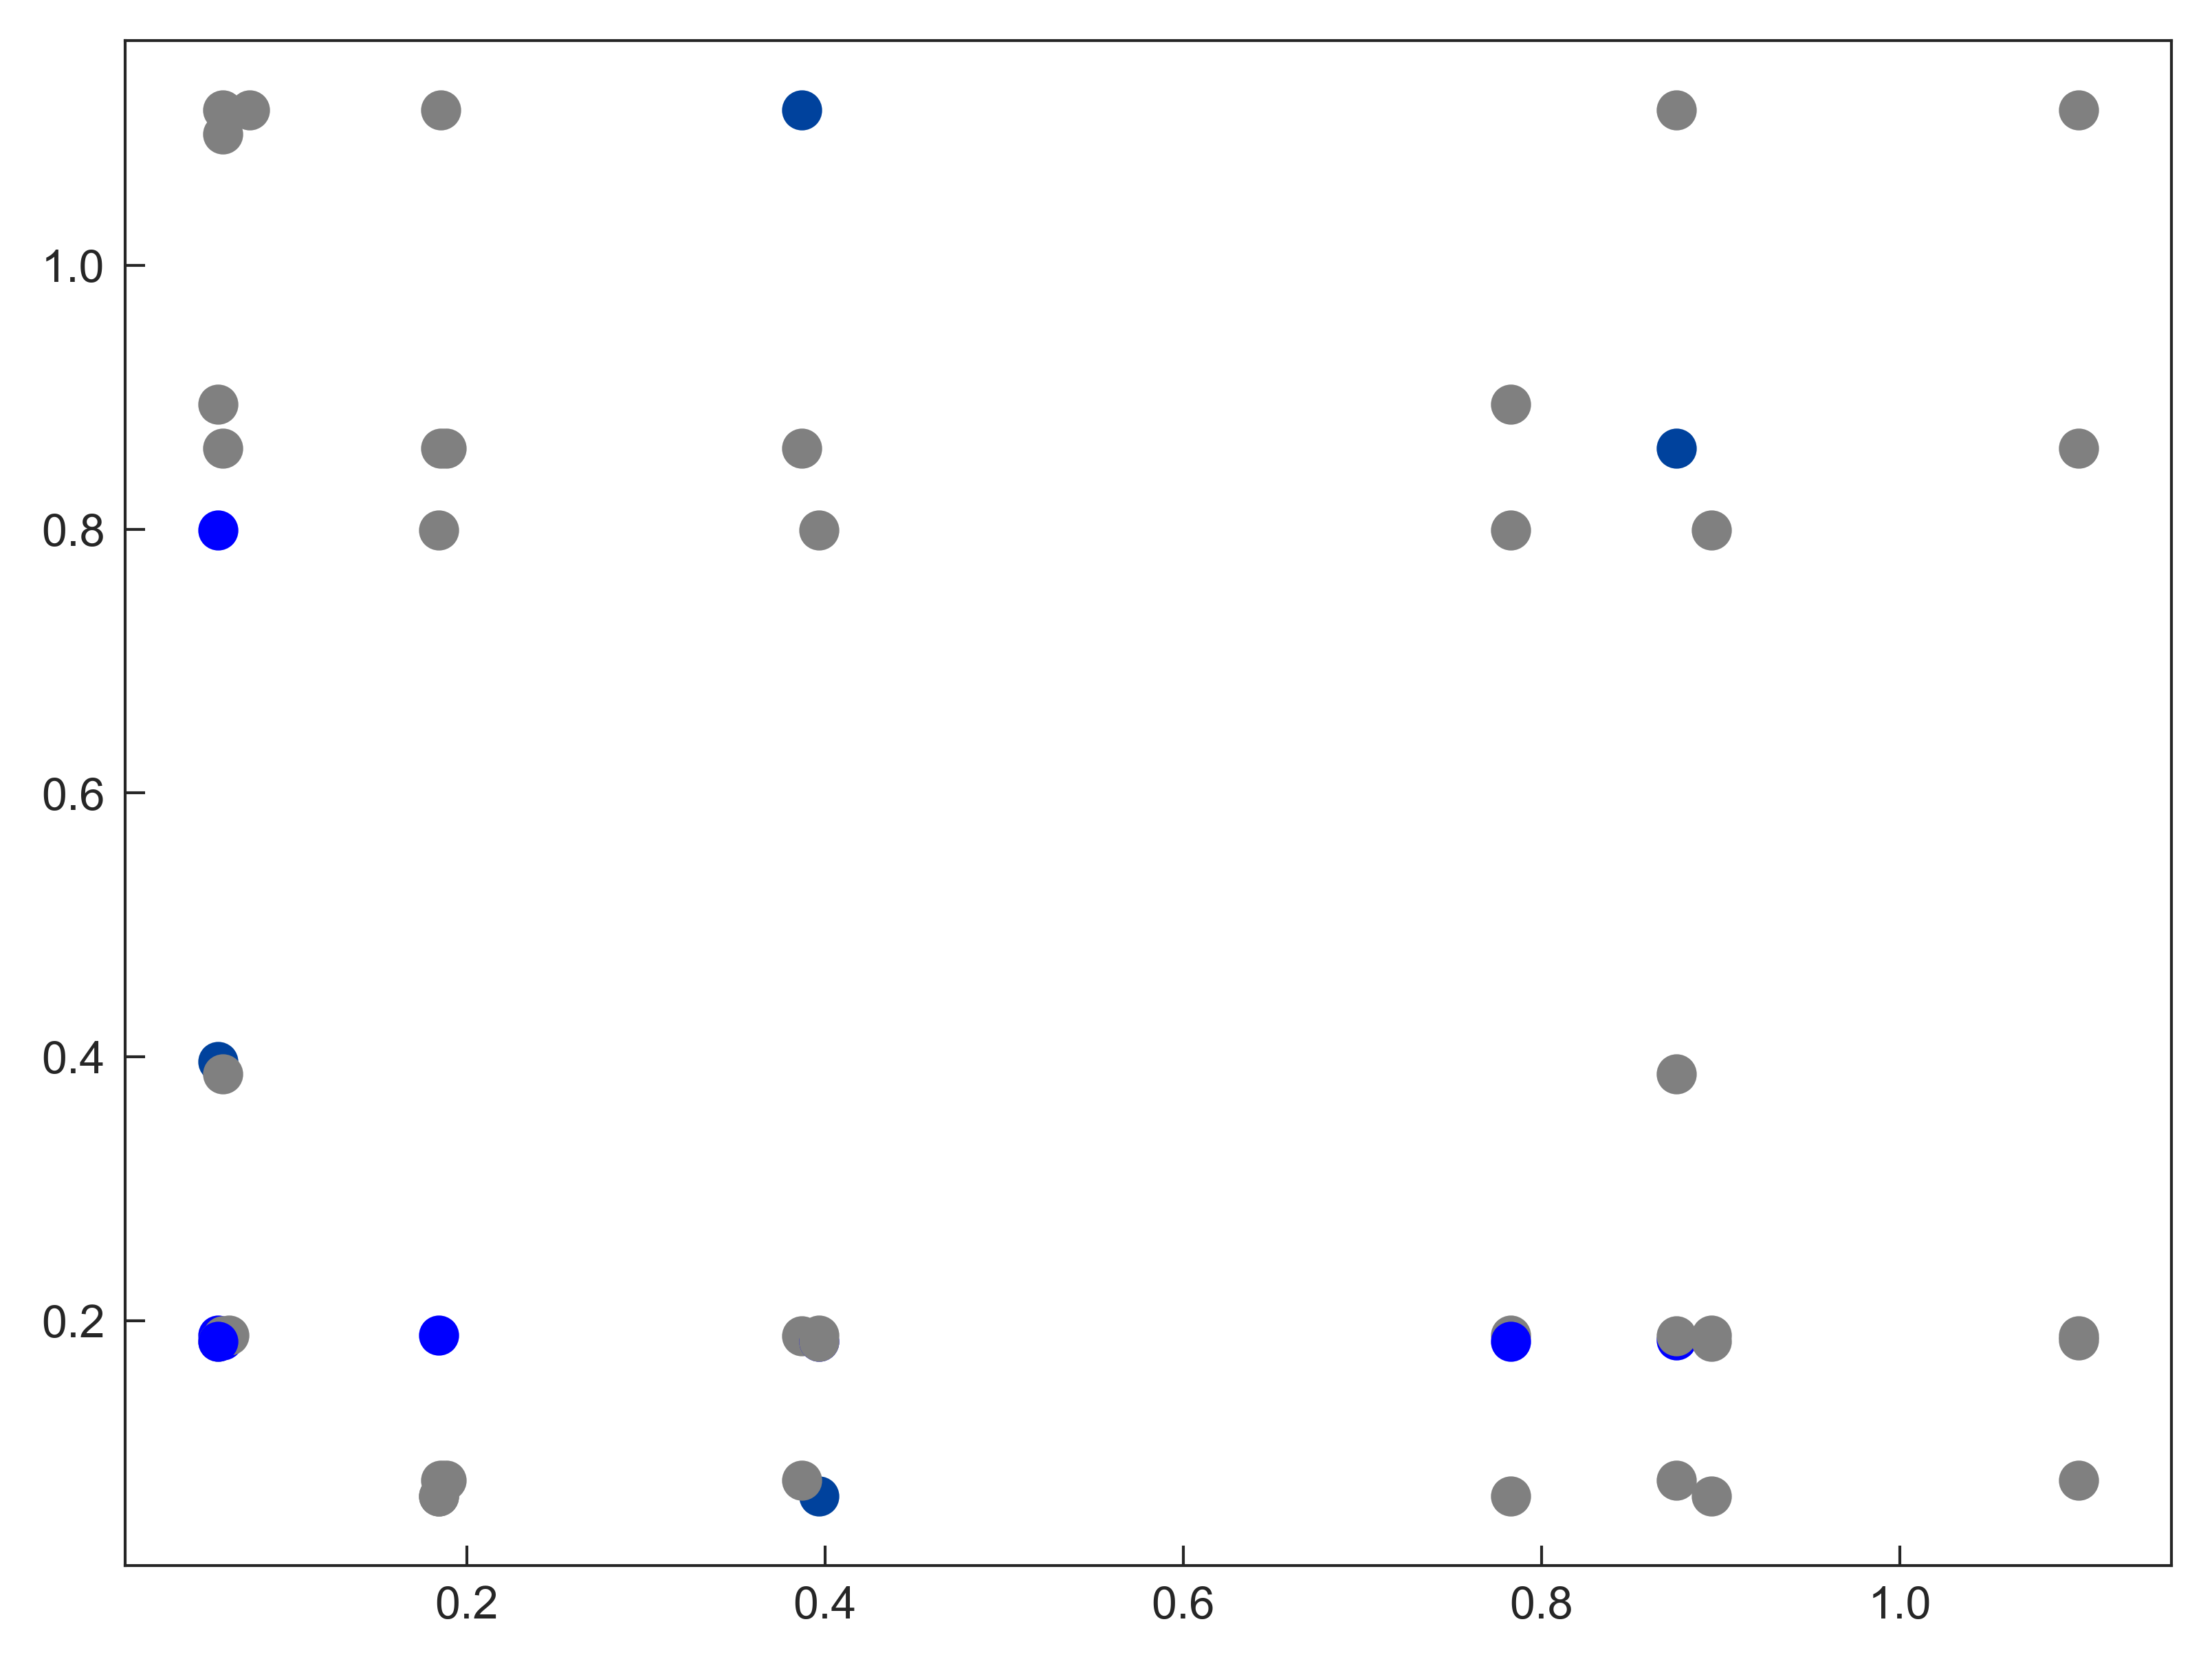

In [ ]:
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):
    OD=OD_data[c_i]
    pH=pH_data[c_i]
    label=label_data[c_i]
    plt.figure()
    for i in range(len(OD)):
        if True:#label[i]==2:
            plt.scatter(OD1_data[c_i][i][-1], OD2_data[c_i][i][-1],color=colors[label[i]])

NameError: name 'u_list' is not defined

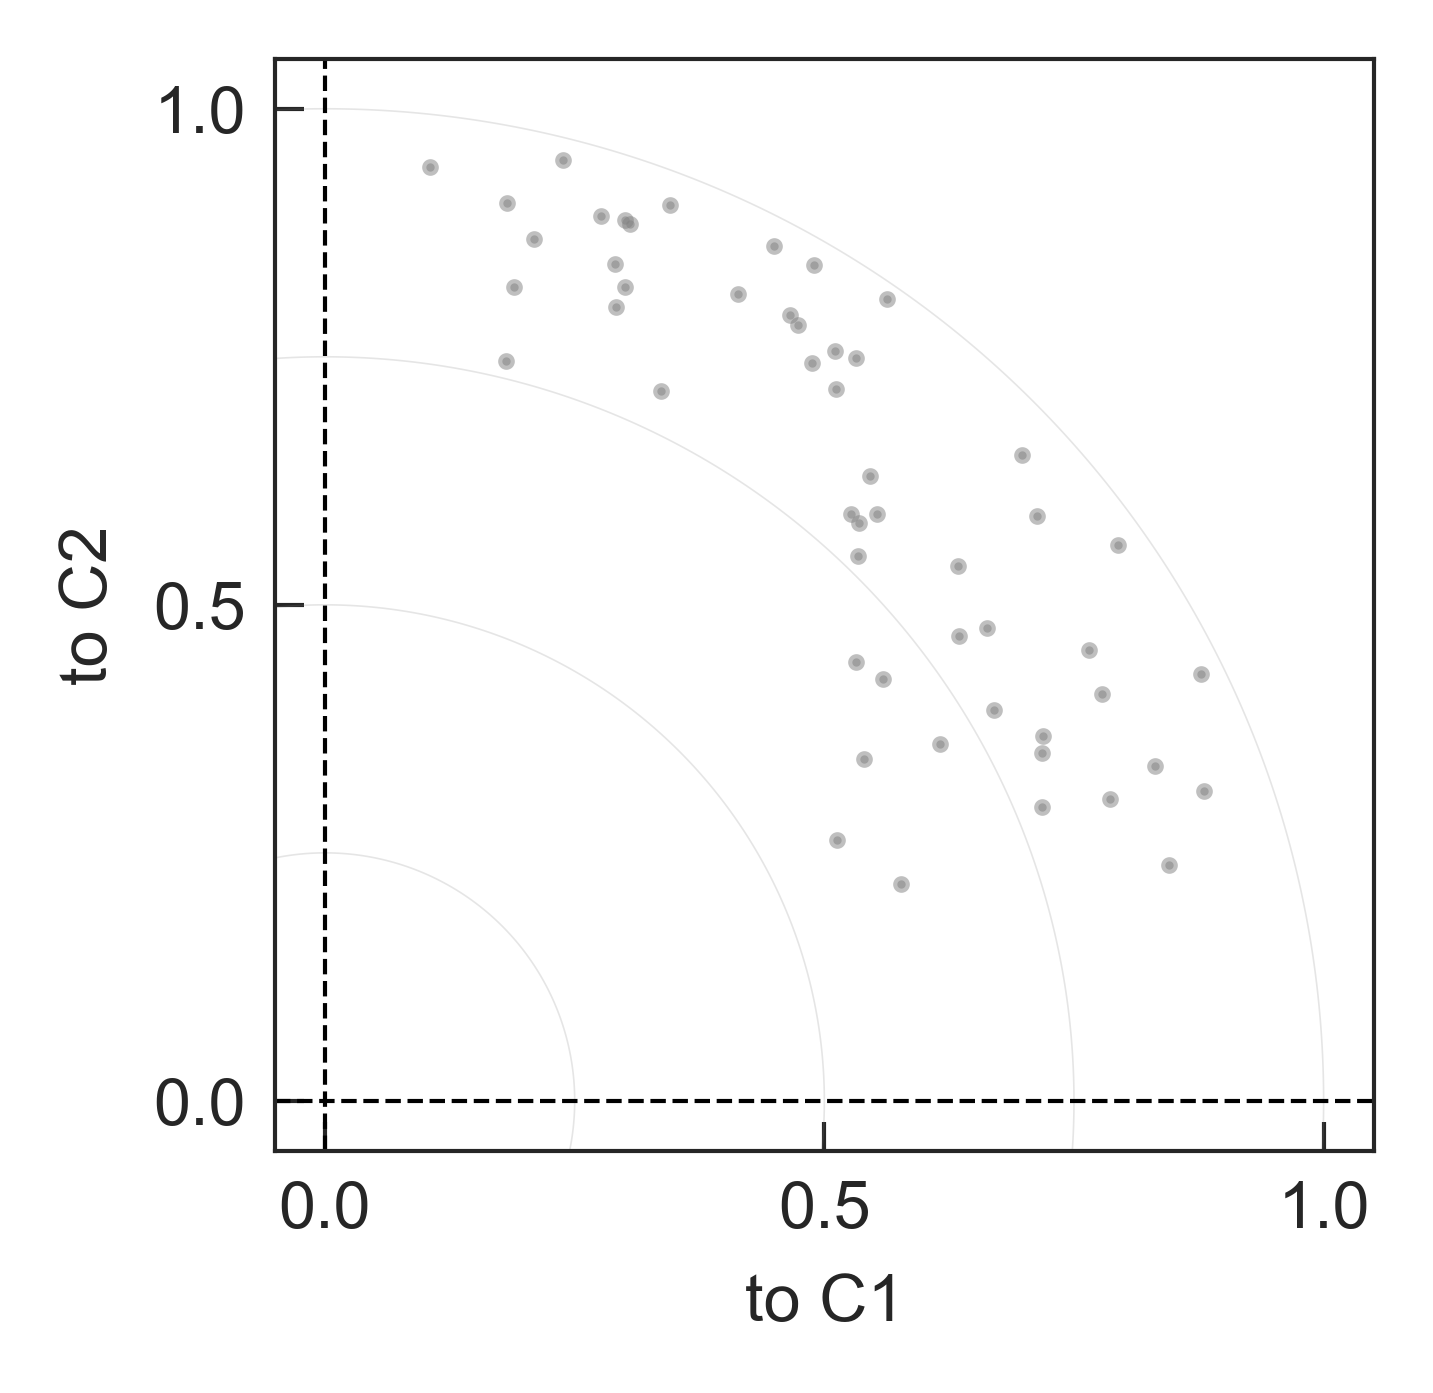

In [ ]:
########################################################
########################################################
# Metric1
########################################################
########################################################

## This figure shows the distribution of "Assymetricity"

## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
# Variable2plot_list=['Threshold_num',
#        'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1',
#        'SimilarityTo1_JS_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1',
#        'SimilarityTo2_JS_1', 'Additivity1_1', 'Additivity2_1',
#        'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1',
#        'Assymetricity_JS_1', 'Assymetricity1_1', 'Assymetricity2_1',
#        'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1',
#        'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2',
#        'SimilarityTo1_J_2', 'SimilarityTo1_JS_2', 'SimilarityTo2_BC_2',
#        'SimilarityTo2_J_2', 'SimilarityTo2_JS_2', 'Additivity1_2',
#        'Additivity2_2', 'Additivity3_2', 'Assymetricity_BC_2',
#        'Assymetricity_J_2', 'Assymetricity_JS_2', 'Assymetricity1_2',
#        'Assymetricity2_2', 'ASVs_notinsub1_2', 'ASVs_notinsub2_2',
#        'ASVs_overlap1_2', 'ASVs_overlap2_2', 'Threshold_level_3',
#        'SimilarityTo1_BC_3', 'SimilarityTo1_J_3', 'SimilarityTo1_JS_3',
#        'SimilarityTo2_BC_3', 'SimilarityTo2_J_3', 'SimilarityTo2_JS_3',
#        'Additivity1_3', 'Additivity2_3', 'Additivity3_3',
#        'Assymetricity_BC_3', 'Assymetricity_J_3', 'Assymetricity_JS_3',
#        'Assymetricity1_3', 'Assymetricity2_3', 'ASVs_notinsub1_3',
#        'ASVs_notinsub2_3', 'ASVs_overlap1_3', 'ASVs_overlap2_3',
#        'Threshold_level_4', 'SimilarityTo1_BC_4', 'SimilarityTo1_J_4',
#        'SimilarityTo1_JS_4', 'SimilarityTo2_BC_4', 'SimilarityTo2_J_4',
#        'SimilarityTo2_JS_4', 'Additivity1_4', 'Additivity2_4',
#        'Additivity3_4', 'Assymetricity_BC_4', 'Assymetricity_J_4',
#        'Assymetricity_JS_4', 'Assymetricity1_4', 'Assymetricity2_4',
#        'ASVs_notinsub1_4', 'ASVs_notinsub2_4', 'ASVs_overlap1_4',
#        'ASVs_overlap2_4', 'Threshold_level_5', 'SimilarityTo1_BC_5',
#        'SimilarityTo1_J_5', 'SimilarityTo1_JS_5', 'SimilarityTo2_BC_5',
#        'SimilarityTo2_J_5', 'SimilarityTo2_JS_5', 'Additivity1_5',
#        'Additivity2_5', 'Additivity3_5', 'Assymetricity_BC_5',
#        'Assymetricity_J_5', 'Assymetricity_JS_5', 'Assymetricity1_5',
#        'Assymetricity2_5', 'ASVs_notinsub1_5', 'ASVs_notinsub2_5',
#        'ASVs_overlap1_5', 'ASVs_overlap2_5']
colors=["grey", my_cmap(0), "blue"]


# Plotting real data
degList=np.zeros(43)
N=50
for c_i,type_name in enumerate(['LN_12', 'MN_12', 'HN_12']):



        #sns.kdeplot(data, shade=True,bw_adjust=.6)


    if True:
        
        data1=data1_set[type_name]
        data2=data2_set[type_name]


        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        scatter(data1,data2,s=1,color=colors[c_i],alpha=0.5)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.2)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.5)
        plt.axvline(0, color='k', linestyle='--', linewidth=.5)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        plt.xlabel('to C1')
        plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        #plt.legend()
        f.savefig(f'Figure/Metric_metric3_{u_list[i]}_style1.svg',bbox_inches='tight')





        